In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re
import sys
import astropy as ast
from astropy.io import ascii, fits
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import pandas as pd
import glob
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm, Normalize
import gzip
import re
import csv
from tqdm import tqdm
# import pysynphot as S
from metrics import fit_plotter_flux, fit_plotter_flux_v2, mean_med_flux, mean_med_flux_v2, offset_warning, offset_warning_v2,compute_lomb_scargle, plot_periodogram,plot_phase_fold
from view_and_clean import individual_plotter, df_extract, individual_plotter_v2, df_extract_v2, offset_corrector
from metrics import sed_plotter, info

In [2]:
coords = pd.read_csv('../merged_smc_lmc_coords_all.csv', comment='#', sep="\\s+", names=['RA', 'DEC'])
df_lmc = pd.read_csv('../ysg_candidates/final_lmc_ysgcands_allphot.csv', comment='#') # , sep="\\s+"
df_smc = pd.read_csv('../ysg_candidates/final_smc_ysgcands_allphot.csv', comment='#') # , sep="\\s+"
df_lmc_prefinal = pd.read_csv('../ysg_candidates/prefinal_lmc_ysgcands_allphot.csv', comment='#') # , sep="\\s+"
df_smc_prefinal = pd.read_csv('../ysg_candidates/prefinal_smc_ysgcands_allphot.csv', comment='#') # , sep="\\s+"
stats = pd.read_csv('../summary_results15.csv')
# set serif font settings for plots
plt.rcParams['font.family'] = 'serif'

In [3]:
# load the Gordon extinction curves for LMC and SMC 
lmc_gordon_file = 'dustmaps_data/extinction_curves/lmc_avg_ext.dat'
smc_gordon_file = 'dustmaps_data/extinction_curves/smc_bar_avg.dat'

lmc_gordon = ascii.read(lmc_gordon_file,comment=';',names=['x','AlamAv','unc'])
lmc_Ang = (1./lmc_gordon['x'])*1e4
lmc_wave = np.flip(lmc_Ang)
lmc_AlamAv = np.flip(lmc_gordon['AlamAv'])

smc_gordon = ascii.read(smc_gordon_file,comment=';',names=['x','AlamAv','unc'])
smc_Ang = (1./smc_gordon['x'])*1e4
smc_wave = np.flip(smc_Ang)
smc_AlamAv = np.flip(smc_gordon['AlamAv'])

In [4]:
# # Add APASS photometry to final candidate files
# from astropy.coordinates import SkyCoord
# from astropy import units as u
# import numpy as np

# # Load the apass data if not already loaded
# if 'apassfile' not in locals():
#     with fits.open('apass_match.fit') as hdul:
#         columns_to_keep = ['RAJ2000', 'DEJ2000', 'Bmag', 'e_Bmag', 'Vmag', 'e_Vmag', 
#                            'gmag', 'e_gmag', 'rmag', 'e_rmag', 'imag', 'e_imag']
#         all_rows = []
#         for i in range(1, len(hdul)):
#             all_rows.append(pd.DataFrame({col: hdul[i].data[col] for col in columns_to_keep}))
#         apassfile = pd.concat(all_rows, ignore_index=True)
#         print(f"Loaded {len(apassfile)} sources from APASS catalog")

# # Create SkyCoord object for APASS catalog
# apass_coords = SkyCoord(ra=apassfile['RAJ2000'].values*u.deg, 
#                         dec=apassfile['DEJ2000'].values*u.deg, 
#                         frame='icrs')

# def add_apass_to_candidates(input_file, output_file):
#     """
#     Add APASS photometry to candidate file by coordinate matching
#     """
#     # Read the candidate file
#     df = pd.read_csv(input_file)
#     print(f"\nProcessing {input_file}")
#     print(f"  Candidates: {len(df)}")
    
#     # Create SkyCoord for candidates
#     cand_coords = SkyCoord(ra=df['ra'].values*u.deg, 
#                            dec=df['dec'].values*u.deg, 
#                            frame='icrs')
    
#     # Find nearest APASS match for each candidate
#     idx, sep2d, _ = cand_coords.match_to_catalog_sky(apass_coords)
    
#     # Define matching tolerance (1 arcsecond)
#     max_sep = 1.0 * u.arcsec
    
#     # Initialize new columns with NaN
#     apass_cols = ['Bmag', 'e_Bmag', 'Vmag', 'e_Vmag', 'gmag', 'e_gmag', 
#                   'rmag', 'e_rmag', 'imag', 'e_imag']
#     for col in apass_cols:
#         df[col + 'apass'] = np.nan
    
#     # Fill in matched sources
#     matches = sep2d < max_sep
#     n_matches = np.sum(matches)
    
#     for i, (matched, apass_idx) in enumerate(zip(matches, idx)):
#         if matched:
#             for col in apass_cols:
#                 df.loc[i, col + 'apass'] = apassfile.loc[apass_idx, col]
    
#     print(f"  Matched to APASS: {n_matches} ({100*n_matches/len(df):.1f}%)")
#     print(f"  No APASS match: {len(df) - n_matches}")
    
#     # Save the updated file
#     df.to_csv(output_file, index=False)
#     print(f"  Saved to {output_file}")
    
#     return df

# Process both files
# lmc_df = add_apass_to_candidates('annas_candidates/final_lmc_ysgcands.csv', 
#                                   'annas_candidates/final_lmc_ysgcands.csv')
# smc_df = add_apass_to_candidates('annas_candidates/final_smc_ysgcands.csv', 
#                                   'annas_candidates/final_smc_ysgcands.csv')

In [5]:
# # Read the file
# df = pd.read_csv('../ysg_candidates/final_smc_ysgcands_allphot_simbad.csv', comment='#')

# # Find all columns matching e_*mag_APASS pattern
# apass_error_cols = [col for col in df.columns if col.startswith('e_') and col.endswith('mag_APASS')]

# # Divide those columns by 100
# df[apass_error_cols] = df[apass_error_cols] / 100

# # Save back to file
# df.to_csv('../ysg_candidates/final_smc_ysgcands_allphot_simbad.csv', index=False)

# print(f"Updated columns: {apass_error_cols}")

## BOSZ models

In [6]:
basepath = '/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/synth_phot_temp_estimation/pysynphot_data/grid/bosz/r2000/'
smcbasepath = '/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/synth_phot_temp_estimation/pysynphot_data/grid/bosz/r2000/m-0.75/'
lmcbasepath = '/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/synth_phot_temp_estimation/pysynphot_data/grid/bosz/r2000/m-0.25/'
wavelengths = np.loadtxt(os.path.join(basepath, 'bosz2024_wave_r2000.txt'))

In [7]:
def parse_bosz_filename(filename, smc=True):
    """
    Parse BOSZ filename to extract stellar parameters
    Example: bosz2024_ms_t4250_g+2.5_m-0.75_a+0.00_c+0.00_v2_r2000_resam.txt.gz
    """
    # Extract parameters using regex
    if smc:
        filename = os.path.join(smcbasepath, filename)
    else:
        filename = os.path.join(lmcbasepath, filename)
    pattern = r'bosz2024_([a-z]+)_t(\d+)_g([+-]?\d+\.?\d*)_m([+-]?\d+\.?\d*)_a([+-]?\d+\.?\d*)_c([+-]?\d+\.?\d*)_v(\d+)_r(\d+)'
    match = re.search(pattern, filename)
    
    if match:
        return {
            'class': match.group(1),
            'teff': int(match.group(2)),  # Temperature in K
            'logg': float(match.group(3)), # log(g)
            'metallicity': float(match.group(4)), # [M/H]
            'alpha': float(match.group(5)), # [α/Fe]
            'carbon': float(match.group(6)), # [C/Fe]
            'vturb': int(match.group(7)),   # Microturbulence km/s
            'resolution': int(match.group(8)) # Spectral resolution
        }
    return None

def find_bosz_models_by_temp(target_temp, temp_tolerance=250):
    """
    Find BOSZ models within temperature tolerance of target
    """
    bosz_dir = '/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/synth_phot_temp_estimation/pysynphot_data/grid/bosz/r2000'
    matching_models = []
    for metallicity_dir in ['m-0.75', 'm-0.25']:
        met_path = os.path.join(bosz_dir, metallicity_dir)
        if os.path.exists(met_path):
            for filename in os.listdir(met_path):
                if filename.endswith('.txt.gz'):
                    params = parse_bosz_filename(filename, smc=(metallicity_dir == 'm-0.75'))
                    if params and abs(params['teff'] - target_temp) <= temp_tolerance:
                        full_path = os.path.join(met_path, filename)
                        params['filepath'] = full_path
                        matching_models.append(params)
    return sorted(matching_models, key=lambda x: abs(x['teff'] - target_temp))

# for temp in [4000, 5000, 6000]:
#     models = find_bosz_models_by_temp(temp, temp_tolerance=500)
#     print(f"\nModels near {temp}K (+/-500K):")
#     for model in models[:3]:  # first 3 matches
#         print(f"  Teff={model['teff']}K, log(g)={model['logg']}, [M/H]={model['metallicity']}")
# parse_bosz_filename("m-0.25/bosz2024_ms_t4250_g+2.5_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz")

In [8]:
def browse_bosz_models(smc=True):
    """
    Interactive function to browse available BOSZ models
    """
    bosz_dir = os.path.join('/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/synth_phot_temp_estimation/pysynphot_data/grid/bosz/r2000')
    all_models = []
    if smc:
        metallicity_dir = 'm-0.75'
    else:
        metallicity_dir = 'm-0.25'

    met_path = os.path.join(bosz_dir, metallicity_dir)
    if os.path.exists(met_path):
        for filename in os.listdir(met_path):
            if filename.endswith('.txt.gz'):
                params = parse_bosz_filename(filename)
                if params:
                    params['filepath'] = os.path.join(met_path, filename)
                    all_models.append(params)
    # Sort by temperature
    all_models.sort(key=lambda x: x['teff'])
    print(f"Total BOSZ models available: {len(all_models)}")
    print("\nTemperature range:", all_models[0]['teff'], "K to", all_models[-1]['teff'], "K")
    print("log(g) range:", min(m['logg'] for m in all_models), "to", max(m['logg'] for m in all_models))
    print("Metallicity value:", sorted(list(set(m['metallicity'] for m in all_models))))
    return all_models

smc_bosz = browse_bosz_models(smc=True)
lmc_bosz = browse_bosz_models(smc=False)
# print(f"\nSample BOSZ model:\n{smc_bosz[0]}")

Total BOSZ models available: 122

Temperature range: 4000 K to 14000 K
log(g) range: 0.0 to 3.0
Metallicity value: [-0.75]
Total BOSZ models available: 120

Temperature range: 4000 K to 14000 K
log(g) range: 0.0 to 3.0
Metallicity value: [-0.25]


In [9]:
def plot_bosz_spectra_test(data):
    """
    Look at the non-dummy portion of BOSZ data to see if there's real spectrum data
    """
    col0 = data[:, 0]
    col1 = data[:, 1]
    
    # Create mask for wavelengths <= 40000 Angstroms
    mask = wavelengths <= 40000
    
    # Apply mask to get filtered data
    wave_filtered = wavelengths[mask]
    flux_filtered = col0[mask]
    continuum_filtered = col1[mask]
            
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(wave_filtered, flux_filtered, 'b.-', markersize=1)
    ax1.set_title('Column 0 (Flux)')
    ax1.set_xlabel('Wavelength (Angstroms)')
    ax1.set_ylabel('Flux Value')
    ax1.grid(True)
    
    ax2.plot(wave_filtered, continuum_filtered, 'r.-', markersize=1)
    ax2.set_title('Column 1 (Continuum)')
    ax2.set_xlabel('Wavelength (Angstroms)')
    ax2.set_ylabel('Continuum Value')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Plotted {len(wave_filtered)} points out of {len(wavelengths)} total points")
    print(f"Wavelength range: {wave_filtered.min():.1f} - {wave_filtered.max():.1f} Angstroms")

# trial run
# data = np.loadtxt('/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/pysynphot_data/grid/bosz/r2000/m-0.75/bosz2024_ms_t4250_g+2.5_m-0.75_a+0.00_c+0.00_v2_r2000_resam.txt.gz')
# plot_bosz_spectra_test(data)

/var/folders/34/3847lqd14j78mfm70_z1c_r00000gn/T/ipykernel_4396/365648523.py:22: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b.-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(wave_filtered, flux_filtered, 'b.-', markersize=1, label=os.path.basename(model), color=colours[filenames_to_test.index(model)], alpha=0.7)


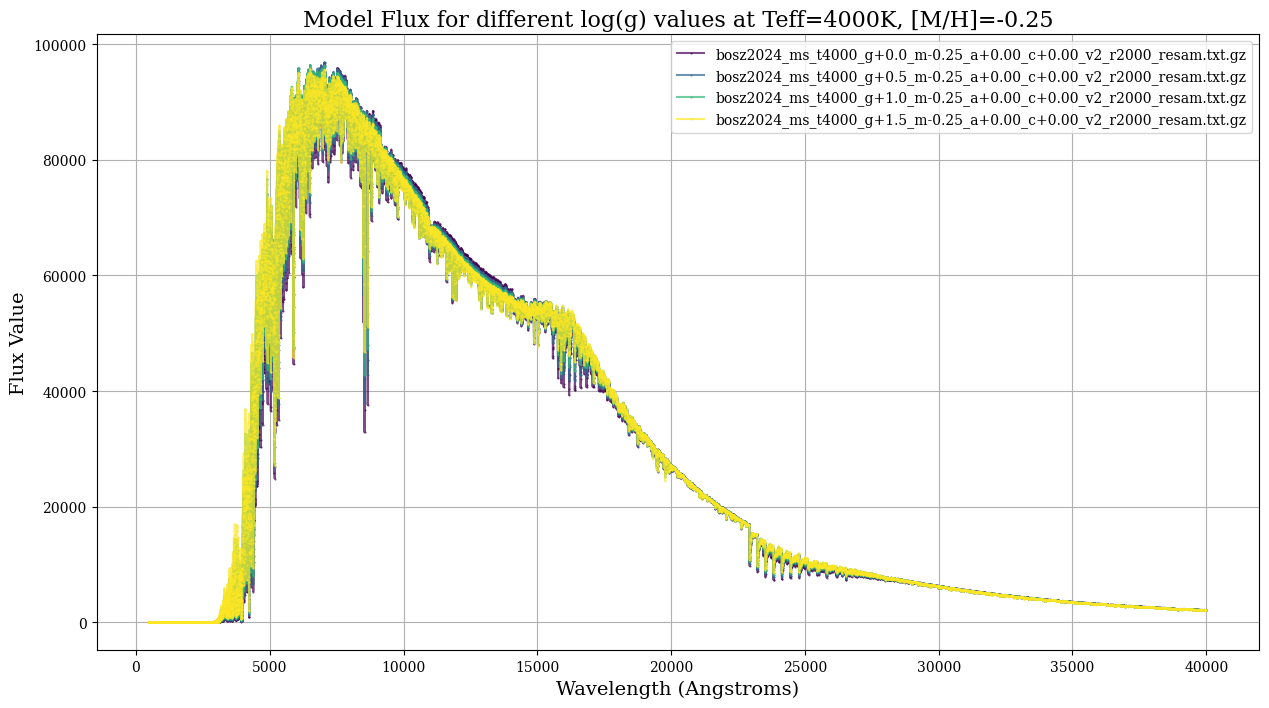

In [10]:
filenames_to_test = [
    '/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/synth_phot_temp_estimation/pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ms_t4000_g+0.0_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
    '/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/synth_phot_temp_estimation/pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ms_t4000_g+0.5_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
    '/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/synth_phot_temp_estimation/pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ms_t4000_g+1.0_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
    '/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/synth_phot_temp_estimation/pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ms_t4000_g+1.5_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz']

fig = plt.figure(figsize=(15, 8))
colours = cm.viridis(np.linspace(0, 1, len(filenames_to_test)))
for model in filenames_to_test:
    data = np.loadtxt(model)  
    col0 = data[:, 0]
    col1 = data[:, 1]

    # Create mask for wavelengths <= 40000 Angstroms
    mask = wavelengths <= 40000

    # Apply mask to get filtered data
    wave_filtered = wavelengths[mask]
    flux_filtered = col0[mask]
    continuum_filtered = col1[mask]

    plt.plot(wave_filtered, flux_filtered, 'b.-', markersize=1, label=os.path.basename(model), color=colours[filenames_to_test.index(model)], alpha=0.7)
plt.title('Model Flux for different log(g) values at Teff=4000K, [M/H]=-0.25', fontsize=16)
plt.xlabel('Wavelength (Angstroms)', fontsize=14)
plt.ylabel('Flux Value', fontsize=14)
plt.legend()
plt.grid(True)

# Compute synthetic photometry

In [11]:
# Functions

def synth_flux(filter_name,model_lam,model_flux):
    '''
    Calculates the synthetic photometric flux for the input model with the
    input filter transmission file.

    Parameters:
    filter_name: The filter file containing the wavelength (Angstroms) 
                    and intensity (erg/s/cm^2/A)
    model_lam: The model wavelengths in Angstroms
    model_flux: The model flux in erg/s/cm^2/A

    Returns:
    flux: The synthetic flux in erg/s/cm^2/A
    '''
    filter_lam = filter_name.columns[0]
    filter_flux = filter_name.columns[1]
    
    f_lam=np.zeros(len(filter_lam))
    for i in range(len(f_lam)):
        # This interpolates the model flux along the same wavelengths as the
        # transmission curve. This needs to be done for the integration to work
        f_lam[i]=np.interp(filter_lam[i],model_lam,model_flux)
    
    # Multiply the (interpolated) model flux by the filter intensity, and integrate
    top = np.trapezoid(np.multiply(f_lam,filter_flux),x=filter_lam)
    # Integrate the filter intensity alone
    bottom = np.trapezoid(filter_flux,x=filter_lam)
    # Divide!
    flux = top/bottom
    
    return flux


def flux_to_mag(flux,zp):
    '''
    Converts a flux to a magnitude given the zero point.

    Parameters:
    flux: flux in erg/s/cm^2/A
    zp: Zero point in erg/s/cm^2/A

    Returns:
    mag: Magnitude
    '''

    mag = (-2.5)*np.log10(flux/zp)

    return mag

def synth_mag(filter_name,model_lam,model_flux,zp):
    '''
    Calculates the synthetic magnitude for the input model using the input
    filter transmission and a zero point.

    Parameters:
    filter_name: The filter file containing the wavelength (Angstroms) 
                    and intensity (erg/s/cm^2/A)
    model_lam: The model wavelengths in Angstroms
    model_flux: The model flux in erg/s/cm^2/A
    zp: Zero point in erg/s/cm^2/A

    Returns:
    mag: Magnitude
    '''

    flux = synth_flux(filter_name,model_lam,model_flux)
    mag = flux_to_mag(flux,zp)
    return mag

In [12]:
# Load in filter functions
col_names=['lam','flux']

tmass_j = ascii.read('./pysynphot_data/grid/bosz/2MASS_2MASS.J_v3.0596e-10_ab7.08741e-10_eff12350.dat', names=col_names, data_start=0)
tmass_h = ascii.read('./pysynphot_data/grid/bosz/2MASS_2MASS.H_v1.11064e-10_ab4.00078e-10_eff16620.dat', names=col_names, data_start=0)
tmass_k = ascii.read('./pysynphot_data/grid/bosz/2MASS_2MASS.Ks_v4.17999e-11_ab2.32482e-10_eff21590.dat', names=col_names, data_start=0)

mcps_U=ascii.read('./pysynphot_data/grid/bosz/Misc_MCPS.U_v4.08739e-9_ab8.23894e-9_eff3706.dat',names=col_names,data_start=0)
mcps_B=ascii.read('./pysynphot_data/grid/bosz/Misc_MCPS.B_v6.21086e-9_ab5.60999e-9_eff4394.dat', names=col_names,data_start=0)
mcps_V=ascii.read('./pysynphot_data/grid/bosz/Misc_MCPS.V_v3.64047e-9_ab3.63812e-9_eff5438.dat', names=col_names,data_start=0)
mcps_I=ascii.read('./pysynphot_data/grid/bosz/Misc_MCPS.I_v9.23651e-10_ab1.45234e-9_eff8568.dat', names=col_names,data_start=0)

swift_uvm2=ascii.read('./pysynphot_data/grid/bosz/Swift_UVOT.UVM2_trn_v4.66117e-9_ab2.15291e-8_eff2246.dat', names=col_names,data_start=0)
swift_uvw1=ascii.read('./pysynphot_data/grid/bosz/Swift_UVOT.UVW1_trn_v4.02204e-9_ab1.57569e-8_eff2715.dat', names=col_names,data_start=0)
swift_uvw2=ascii.read('./pysynphot_data/grid/bosz/Swift_UVOT.UVW2_trn_v5.37469e-9_2.59051e-8_eff2075.dat', names=col_names,data_start=0)  

# Additional bands:
apass_B=ascii.read('./pysynphot_data/grid/bosz/Generic_Johnson.B.dat', names=col_names,data_start=0)
apass_V=ascii.read('./pysynphot_data/grid/bosz/Generic_Johnson.V.dat', names=col_names,data_start=0)
apass_g=ascii.read('./pysynphot_data/grid/bosz/SLOAN_SDSS.g.dat', names=col_names,data_start=0)
apass_r=ascii.read('./pysynphot_data/grid/bosz/SLOAN_SDSS.r.dat', names=col_names,data_start=0)
apass_i=ascii.read('./pysynphot_data/grid/bosz/SLOAN_SDSS.i.dat', names=col_names,data_start=0)

#Gaia:
gaia_U=ascii.read('./pysynphot_data/grid/bosz/Generic_Johnson.U.dat', names=col_names,data_start=0)
gaia_B=ascii.read('./pysynphot_data/grid/bosz/Generic_Johnson.B.dat', names=col_names,data_start=0)
gaia_V=ascii.read('./pysynphot_data/grid/bosz/Generic_Johnson.V.dat', names=col_names,data_start=0)
gaia_I=ascii.read('./pysynphot_data/grid/bosz/Generic_Johnson.I.dat', names=col_names,data_start=0)
gaia_r=ascii.read('./pysynphot_data/grid/bosz/SLOAN_SDSS.r.dat', names=col_names,data_start=0)
gaia_g=ascii.read('./pysynphot_data/grid/bosz/SLOAN_SDSS.g.dat', names=col_names,data_start=0)
gaia_i=ascii.read('./pysynphot_data/grid/bosz/SLOAN_SDSS.i.dat', names=col_names,data_start=0)

smash_U=ascii.read('./pysynphot_data/grid/bosz/CTIO_DECam.u.dat', names=col_names,data_start=0)
smash_G=ascii.read('./pysynphot_data/grid/bosz/CTIO_DECam.g.dat', names=col_names,data_start=0)
smash_R=ascii.read('./pysynphot_data/grid/bosz/CTIO_DECam.r.dat', names=col_names,data_start=0)
smash_I=ascii.read('./pysynphot_data/grid/bosz/CTIO_DECam.i.dat', names=col_names,data_start=0)
smash_Z=ascii.read('./pysynphot_data/grid/bosz/CTIO_DECam.z.dat', names=col_names,data_start=0)


# Vega zero points for conversion to ergs/s/cm^2/Angstrom
tmass_j_zp = 3.129e-10
tmass_h_zp = 1.133e-10
tmass_k_zp = 4.283e-11
mcps_U_zp = 4.08739e-9
mcps_B_zp = 6.21086e-9
mcps_V_zp = 3.64047e-9
mcps_I_zp = 9.23651e-10
swift_uvm2_zp = 4.66117e-9
swift_uvw1_zp = 4.02204e-9
swift_uvw2_zp = 5.37469e-9
# Additional bands:
apass_B_zp = 6.72553e-9
apass_V_zp = 3.636e-9
apass_g_zp = 4.92255e-9
apass_r_zp = 2.85425e-9
apass_i_zp = 1.94038e-9
# gaia:
gaia_U_zp = 3.49719e-9    # U-band
gaia_B_zp = 6.72553e-9    # B-band
gaia_V_zp = 3.5833e-9    # V-band
gaia_I_zp = 9.23651e-10    # I-band
gaia_g_zp = 5.45476e-9    # g-band
gaia_r_zp = 2.49767e-9    # r-band
gaia_i_zp = 1.38589e-9

smash_U_zp = 7.48186e-9
smash_G_zp = 4.70792e-9
smash_R_zp = 2.64299e-9
smash_I_zp = 1.78253e-9
smash_Z_zp = 1.29484e-9

apassband_wavelength = [4369.53,
                        5467.57,
                        4671.78,
                        6141.12,
                        7457.89]

gaia_wavelength = {
        'FU': 3551.05,        # U gaia
        'FB': 4369.53,        # B gaia
        'FV': 5467.57,        # V gaia
        'FI': 8568.89,        # I gaia
        'Fr': 6141.12,        # r gaia
        'Fg': 4671.78}

smashband_wavelength = [3856.88,
                    4769.90,
                    6370.44,
                    7774.30,
                    9154.88]

# Band wavelengths for plotting
band_wavelengths = {
    'J_2MASS': 12350.0,  
    'H_2MASS': 16620.0,   
    'K_2MASS': 21590.0,   
    'U_MCPS': 3706.29,  
    'B_MCPS': 4394.48,      
    'V_MCPS': 5438.23,   
    'I_MCPS': 8568.89,     
    'uvm2_SWIFT': 2246.56,  
    'uvw1_SWIFT': 2715.68,   
    'uvw2_SWIFT': 2075.69    
}


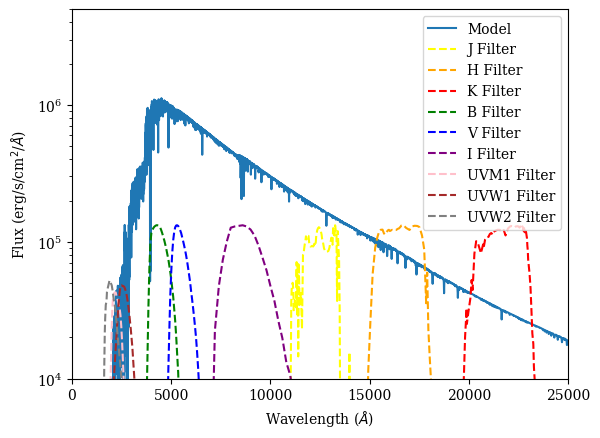

In [13]:
# Load in example spectrum
wave=ascii.read('./pysynphot_data/grid/bosz/r2000/bosz2024_wave_r2000.txt',
                   names=['wave'],data_start=0)
ex_flux=ascii.read('./pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ms_t6000_g+1.0_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
                   names=['flux','cont'],data_start=0)
# print(np.min(ex_wave), np.max(ex_wave))

plt.plot(wave['wave'],ex_flux['flux'],
         '-',c='C0',label='Model')
plt.plot(tmass_j['lam'],tmass_j['flux']*np.mean(ex_flux['flux']),
         '--',c='yellow',label='J Filter')
plt.plot(tmass_h['lam'],tmass_h['flux']*np.mean(ex_flux['flux']),
         '--',c='orange',label='H Filter')
plt.plot(tmass_k['lam'],tmass_k['flux']*np.mean(ex_flux['flux']),
         '--',c='red',label='K Filter')
plt.plot(mcps_B['lam'],mcps_B['flux']*np.mean(ex_flux['flux']),
         '--',c='green',label='B Filter')
plt.plot(mcps_V['lam'],mcps_V['flux']*np.mean(ex_flux['flux']),
         '--',c='blue',label='V Filter')
plt.plot(mcps_I['lam'],mcps_I['flux']*np.mean(ex_flux['flux']),
         '--',c='purple',label='I Filter')
plt.plot(swift_uvm2['lam'],swift_uvm2['flux']*np.mean(ex_flux['flux']),
         '--',c='pink',label='UVM1 Filter')
plt.plot(swift_uvw1['lam'],swift_uvw1['flux']*np.mean(ex_flux['flux']),
         '--',c='brown',label='UVW1 Filter')
plt.plot(swift_uvw2['lam'],swift_uvw2['flux']*np.mean(ex_flux['flux']),
         '--',c='gray',label='UVW2 Filter')

plt.yscale('log')
plt.xlim(0,25000)
plt.ylim(1e4,5e6)
plt.xlabel(r'Wavelength ($\AA$)')
plt.ylabel(r'Flux (erg/s/cm$^2$/$\AA$)')
plt.legend()

In [14]:
def compute_synth_photometry(ex_wave, ex_flux):
    # 2MASS NIR bands
    jmag = synth_mag(tmass_j, ex_wave['wave'], ex_flux['flux'], tmass_j_zp)
    hmag = synth_mag(tmass_h, ex_wave['wave'], ex_flux['flux'], tmass_h_zp)
    kmag = synth_mag(tmass_k, ex_wave['wave'], ex_flux['flux'], tmass_k_zp)
    
    # MCPS optical bands
    Umag_mcps = synth_mag(mcps_U, ex_wave['wave'], ex_flux['flux'], mcps_U_zp)
    Bmag_mcps = synth_mag(mcps_B, ex_wave['wave'], ex_flux['flux'], mcps_B_zp)
    Vmag_mcps = synth_mag(mcps_V, ex_wave['wave'], ex_flux['flux'], mcps_V_zp)
    Imag_mcps = synth_mag(mcps_I, ex_wave['wave'], ex_flux['flux'], mcps_I_zp)
    
    # APASS optical bands
    Bmag_apass = synth_mag(apass_B, ex_wave['wave'], ex_flux['flux'], apass_B_zp)
    Vmag_apass = synth_mag(apass_V, ex_wave['wave'], ex_flux['flux'], apass_V_zp)
    gmag_apass = synth_mag(apass_g, ex_wave['wave'], ex_flux['flux'], apass_g_zp)
    rmag_apass = synth_mag(apass_r, ex_wave['wave'], ex_flux['flux'], apass_r_zp)
    imag_apass = synth_mag(apass_i, ex_wave['wave'], ex_flux['flux'], apass_i_zp)

    # gaia optical bands
    Umag_gaia = synth_mag(gaia_U, ex_wave['wave'], ex_flux['flux'], gaia_U_zp)
    Bmag_gaia = synth_mag(gaia_B, ex_wave['wave'], ex_flux['flux'], gaia_B_zp)
    Vmag_gaia = synth_mag(gaia_V, ex_wave['wave'], ex_flux['flux'], gaia_V_zp)
    Imag_gaia = synth_mag(gaia_I, ex_wave['wave'], ex_flux['flux'], gaia_I_zp)
    rmag_gaia = synth_mag(gaia_r, ex_wave['wave'], ex_flux['flux'], gaia_r_zp)
    gmag_gaia = synth_mag(gaia_g, ex_wave['wave'], ex_flux['flux'], gaia_g_zp)
    imag_gaia = synth_mag(gaia_i, ex_wave['wave'], ex_flux['flux'], gaia_i_zp)

    # SMASH optical bands
    Umag_smash = synth_mag(smash_U, ex_wave['wave'], ex_flux['flux'], smash_U_zp)
    Gmag_smash = synth_mag(smash_G, ex_wave['wave'], ex_flux['flux'], smash_G_zp)
    Rmag_smash = synth_mag(smash_R, ex_wave['wave'], ex_flux['flux'], smash_R_zp)
    Imag_smash = synth_mag(smash_I, ex_wave['wave'], ex_flux['flux'], smash_I_zp)
    Zmag_smash = synth_mag(smash_Z, ex_wave['wave'], ex_flux['flux'], smash_Z_zp)
    
    # SWIFT UV bands
    uvm2_mag = synth_mag(swift_uvm2, ex_wave['wave'], ex_flux['flux'], swift_uvm2_zp)
    uvw1_mag = synth_mag(swift_uvw1, ex_wave['wave'], ex_flux['flux'], swift_uvw1_zp)
    uvw2_mag = synth_mag(swift_uvw2, ex_wave['wave'], ex_flux['flux'], swift_uvw2_zp)
    
    # Convert to fluxes
    jflux = tmass_j_zp * 10**(-0.4 * jmag)
    hflux = tmass_h_zp * 10**(-0.4 * hmag)
    kflux = tmass_k_zp * 10**(-0.4 * kmag)
    
    Uflux_mcps = mcps_U_zp * 10**(-0.4 * Umag_mcps)
    Bflux_mcps = mcps_B_zp * 10**(-0.4 * Bmag_mcps)
    Vflux_mcps = mcps_V_zp * 10**(-0.4 * Vmag_mcps)
    Iflux_mcps = mcps_I_zp * 10**(-0.4 * Imag_mcps)
    
    Bflux_apass = apass_B_zp * 10**(-0.4 * Bmag_apass)
    Vflux_apass = apass_V_zp * 10**(-0.4 * Vmag_apass)
    gflux_apass = apass_g_zp * 10**(-0.4 * gmag_apass)
    rflux_apass = apass_r_zp * 10**(-0.4 * rmag_apass)
    iflux_apass = apass_i_zp * 10**(-0.4 * imag_apass)

    Uflux_gaia = gaia_U_zp * 10**(-0.4 * Umag_gaia)
    Bflux_gaia = gaia_B_zp * 10**(-0.4 * Bmag_gaia)
    Vflux_gaia = gaia_V_zp * 10**(-0.4 * Vmag_gaia)
    Iflux_gaia = gaia_I_zp * 10**(-0.4 * Imag_gaia)
    rflux_gaia = gaia_r_zp * 10**(-0.4 * rmag_gaia)
    gflux_gaia = gaia_g_zp * 10**(-0.4 * gmag_gaia)
    iflux_gaia = gaia_i_zp * 10**(-0.4 * imag_gaia)

    Uflux_smash = smash_U_zp * 10**(-0.4 * Umag_smash)
    Gflux_smash = smash_G_zp * 10**(-0.4 * Gmag_smash)
    Rflux_smash = smash_R_zp * 10**(-0.4 * Rmag_smash)
    Iflux_smash = smash_I_zp * 10**(-0.4 * Imag_smash)
    Zflux_smash = smash_Z_zp * 10**(-0.4 * Zmag_smash)
    
    uvm2_flux = swift_uvm2_zp * 10**(-0.4 * uvm2_mag)
    uvw1_flux = swift_uvw1_zp * 10**(-0.4 * uvw1_mag)
    uvw2_flux = swift_uvw2_zp * 10**(-0.4 * uvw2_mag)


    ### gaia: go from flux to mag
    
    # Dictionary with survey-specific band names as keys
    synth_phot = {
        # 2MASS NIR
        'J_2MASS': {'mag': jmag, 'flux': jflux},
        'H_2MASS': {'mag': hmag, 'flux': hflux},
        'K_2MASS': {'mag': kmag, 'flux': kflux},
        # MCPS optical
        'U_MCPS': {'mag': Umag_mcps, 'flux': Uflux_mcps},
        'B_MCPS': {'mag': Bmag_mcps, 'flux': Bflux_mcps},
        'V_MCPS': {'mag': Vmag_mcps, 'flux': Vflux_mcps},
        'I_MCPS': {'mag': Imag_mcps, 'flux': Iflux_mcps},
        # APASS optical
        'B_APASS': {'mag': Bmag_apass, 'flux': Bflux_apass},
        'V_APASS': {'mag': Vmag_apass, 'flux': Vflux_apass},
        'g_APASS': {'mag': gmag_apass, 'flux': gflux_apass},
        'r_APASS': {'mag': rmag_apass, 'flux': rflux_apass},
        'i_APASS': {'mag': imag_apass, 'flux': iflux_apass},
        # gaia optical
        'U_GAIA': {'mag': Umag_gaia, 'flux': Uflux_gaia},
        'B_GAIA': {'mag': Bmag_gaia, 'flux': Bflux_gaia},
        'V_GAIA': {'mag': Vmag_gaia, 'flux': Vflux_gaia},
        'I_GAIA': {'mag': Imag_gaia, 'flux': Iflux_gaia},
        'r_GAIA': {'mag': rmag_gaia, 'flux': rflux_gaia},
        'g_GAIA': {'mag': gmag_gaia, 'flux': gflux_gaia},
        'i_GAIA': {'mag': imag_gaia, 'flux': iflux_gaia},
        # SMASH optical
        'U_SMASH': {'mag': Umag_smash, 'flux': Uflux_smash},
        'G_SMASH': {'mag': Gmag_smash, 'flux': Gflux_smash},
        'R_SMASH': {'mag': Rmag_smash, 'flux': Rflux_smash},
        'I_SMASH': {'mag': Imag_smash, 'flux': Iflux_smash},
        'Z_SMASH': {'mag': Zmag_smash, 'flux': Zflux_smash},
        # SWIFT UV
        'uvw1_SWIFT': {'mag': uvw1_mag, 'flux': uvw1_flux},
        'uvw2_SWIFT': {'mag': uvw2_mag, 'flux': uvw2_flux},
        'uvm2_SWIFT': {'mag': uvm2_mag, 'flux': uvm2_flux}
    }
    
    return synth_phot

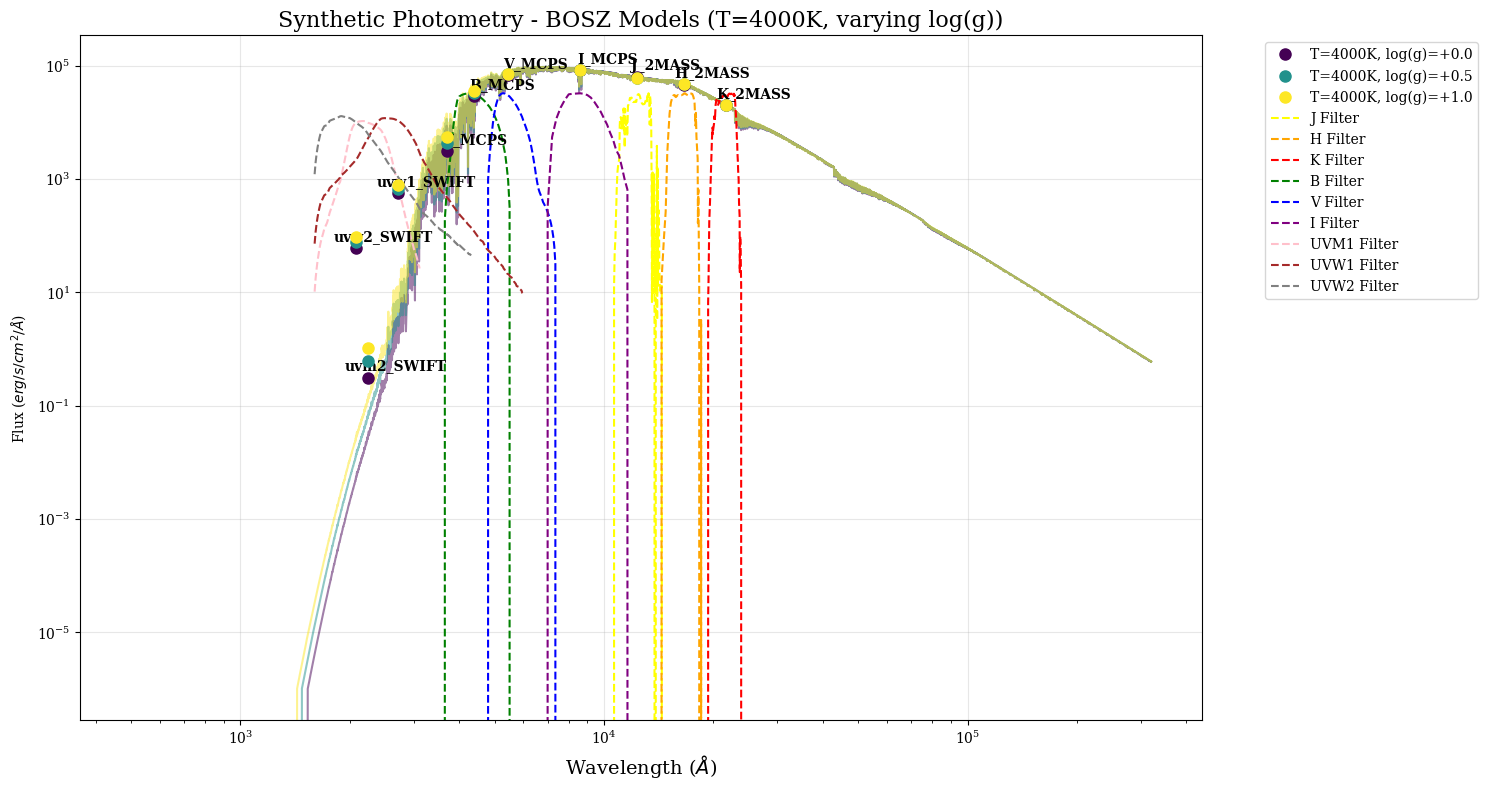

In [15]:
filenames_to_test = [
    '/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/synth_phot_temp_estimation/pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ms_t4000_g+0.0_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
    '/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/synth_phot_temp_estimation/pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ms_t4000_g+0.5_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz',
    '/Users/shannonbowes/Research/ysg/candidates_and_lcs/2022_asassn_lc_data/synth_phot_temp_estimation/pysynphot_data/grid/bosz/r2000/m-0.25/bosz2024_ms_t4000_g+1.0_m-0.25_a+0.00_c+0.00_v2_r2000_resam.txt.gz']

# Define the correct order and names to match compute_synth_photometry output
synth_band_names = ['J_2MASS', 'H_2MASS', 'K_2MASS', 'U_MCPS', 'B_MCPS', 'V_MCPS', 'I_MCPS', 'uvm2_SWIFT', 'uvw1_SWIFT', 'uvw2_SWIFT']
synth_wavelengths = [band_wavelengths[band] for band in synth_band_names]
fig, ax = plt.subplots(figsize=(15, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(filenames_to_test)))

# Store first model's magnitudes for band labeling
first_model_mags = None
first_model_flux = None

for i, model in enumerate(filenames_to_test):
    data = np.loadtxt(model)
    # Create a dictionary-like structure that the function expects
    flux_data = {'flux': data[:,0]}
    synth_phot = compute_synth_photometry(wave, flux_data) 
    points_mag = [synth_phot[band]['mag'] for band in synth_band_names]
    points_flux = [synth_phot[band]['flux'] for band in synth_band_names]
    
    # Store first model's magnitudes for consistent band labeling
    if i == 0:
        first_model_mags = points_mag
        first_model_flux = points_flux
    
    # Parse model parameters from filename for label
    import re
    match = re.search(r't(\d+)_g([+-]?\d+\.?\d*)', os.path.basename(model))
    if match:
        teff = match.group(1)
        logg = match.group(2)
        model_label = f'T={teff}K, log(g)={logg}'
    else:
        model_label = os.path.basename(model)
   # Scale the flux to be comparable to the magnitude range
    ax.plot(wave['wave'], flux_data['flux'], color=colors[i], alpha=0.5) 
    # Plot with correct wavelength-magnitude pairs
#     ax.plot(synth_wavelengths, points_mag, 'o', color=colors[i], 
#             label=model_label, markersize=8, linewidth=2, alpha=0.8)
    ax.plot(synth_wavelengths, points_flux, 'o', color=colors[i], 
            label=model_label, markersize=8, linewidth=2, zorder = 10)

ax.plot(tmass_j['lam'],tmass_j['flux']*np.mean(points_flux),
        '--',c='yellow',label='J Filter')
ax.plot(tmass_h['lam'],tmass_h['flux']*np.mean(points_flux),
        '--',c='orange',label='H Filter')
ax.plot(tmass_k['lam'],tmass_k['flux']*np.mean(points_flux),
        '--',c='red',label='K Filter')
ax.plot(mcps_B['lam'],mcps_B['flux']*np.mean(points_flux),
        '--',c='green',label='B Filter')
ax.plot(mcps_V['lam'],mcps_V['flux']*np.mean(points_flux),
        '--',c='blue',label='V Filter')
ax.plot(mcps_I['lam'],mcps_I['flux']*np.mean(points_flux),
        '--',c='purple',label='I Filter')
ax.plot(swift_uvm2['lam'],swift_uvm2['flux']*np.mean(points_flux),
        '--',c='pink',label='UVM1 Filter')
ax.plot(swift_uvw1['lam'],swift_uvw1['flux']*np.mean(points_flux),
        '--',c='brown',label='UVW1 Filter')
ax.plot(swift_uvw2['lam'],swift_uvw2['flux']*np.mean(points_flux),
        '--',c='gray',label='UVW2 Filter')
# Add band name labels only once, using the first model's positions
for j, (wl, mag, band) in enumerate(zip(synth_wavelengths, first_model_mags, synth_band_names)):
    ax.annotate(band, (wl, mag), xytext=(20, 5), textcoords='offset points', 
               fontsize=10, ha='center', fontweight='bold')
for j, (wl, mag, band) in enumerate(zip(synth_wavelengths, first_model_flux, synth_band_names)):
    ax.annotate(band, (wl, mag), xytext=(20, 5), textcoords='offset points', 
               fontsize=10, ha='center', fontweight='bold')
ax.set_xlabel('Wavelength ($\\AA$)', fontsize=14)
ax.set_ylabel('Flux ($erg/s/cm^2/\\AA$)')
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_title('Synthetic Photometry - BOSZ Models (T=4000K, varying log(g))', fontsize=16)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Functions
def rchi2_with_err(star_mags,star_err,model_mags):
    '''
    Returns the reduced chi^2, accounting for errors
    Parameters:
        star_mags: Observed magnitudes
        star_err: Uncertainty on the observed magnitudes
        model_mags: Model magnitudes
    Returns:
        rchi2: Reduced chi^2 value
    '''
    N = len(star_mags)
    z = (star_mags-model_mags)/star_err
    rchi2 = np.sum(z**2)/(N-1)
    return rchi2

In [17]:
def Cardelli_redden(wave,flux,Av=0,Rv=3.1):
    '''Will redden an input spectrum based on the Cardelli law:
    
    Parameters:
    wave (angstrom): wavelengths of input spectrum in Angstrom
    flux (erg/s/cm/Ang): flux of spectrum; scaled version of this flux are fine.
    Av:
    Rv:
    
    Returns: a new flux array in same units as input
    '''
    wave_micon=wave*1.0e-4
    wave_inverse=1.0/wave_micon
    
    A_lambda=np.zeros(len(wave))
    ax=np.zeros(len(wave))
    bx=np.zeros(len(wave))
    
    for i in range(len(wave)):
        if((wave_inverse[i] > 0.3) and (wave_inverse[i] < 1.1)):
            ax[i]=0.574*wave_inverse[i]**1.61
            bx[i]=-0.527*wave_inverse[i]**1.61
        if((wave_inverse[i] > 1.1) and (wave_inverse[i] < 3.3)):
            y=wave_inverse[i] - 1.82
            ax[i]=1+ 0.17699*y - 0.50447*y**2. - 0.02427*y**3.+0.72085*y**4.+0.01979*y**5.-0.77530*y**6.+0.32999*y**7.
            bx[i]=1.41338*y+2.28305*y**2.+1.07233*y**3.-5.38434*y**4.-0.62251*y**5.+5.30260*y**6.-2.09002*y**7.
        if((wave_inverse[i] > 3.3) and (wave_inverse[i] < 8.0)):
            if(wave_inverse[i] > 5.9):
                Fa=-0.04473*(wave_inverse[i] - 5.9)**2.-0.009779*(wave_inverse[i]-5.9)**3.
                Fb=0.2130*(wave_inverse[i] - 5.9)**2. +0.1207*(wave_inverse[i] -5.9)**3.
            else:
                Fa = 0.0
                Fb = 0.0

            ax[i]=1.752 - 0.316*wave_inverse[i]-0.104/((wave_inverse[i]-4.67)**2.+0.341) +Fa
            bx[i]=-3.090+1.825*wave_inverse[i]+1.206/((wave_inverse[i] - 4.62)**2.+0.263) +Fb
    A_lambda=(ax+bx/Rv)*Av
    #print(A_lambda)
    NewSpec=flux*10.**(-0.4*A_lambda)
    results = NewSpec
    return results

In [18]:
def gordon_redden(wave, flux, Av, wave_gordon, AlamAv):
    """Will redden an input spectrum based on the Gordon's Extinction Curve:

    Parameters:
    wave (angstrom): wavelengths of input spectrum in Angstrom
    flux (erg/s/cm/Ang): flux of spectrum; scaled version of this flux are fine.
    Av: Amount to de-redden by
    wave_gordon (Angstrom): wavelengths associated with the Gordon Curve
    AlamAv: associated array of Alambda/Av values for Gordon curve.

    Returns: a new flux array in same units as input
    """

    # Interpolate Gordone to the wavelengths of Spectrum:
    AlamAv_interp = np.interp(wave,wave_gordon,AlamAv)
    A_lambda = Av * AlamAv_interp

    #############
    NewSpec = flux * 10.0 ** (-0.4 * A_lambda)

    return NewSpec

In [19]:
def get_ebv(ra,dec):
    """
    Collects E(B-V) values for a star location. Produces a 'minimum' E(B-V)
    from the Edenhofer 23 3D map, and a 'mean' E(B-V) from the SFD map,
    modified with the recalibration from SF 2011. 

    Parameters:
        ra - Right Ascension in decimal degrees
        dec - Declination in decimal degrees

    Returns:
        ebv_eden - Minimum E(B-V) from Edenhofer 23
        ebv_sf - 'Average' E(B-V) from SFD with the SF alteration
    
    """ 

    coords_eden=SkyCoord(ra*u.degree,dec*u.degree,
                         distance=1.24*u.kpc,frame='icrs') # Distance is max distance for this map
    ebv_eden=eden(coords_eden)

    coords_sf=SkyCoord(ra*u.degree,dec*u.degree,frame='icrs')
    ebv_sfd=sfd(coords_sf)
    ebv_sf=0.86*ebv_sfd # To fix from the older SFD value to the newer SF value

    return ebv_eden, ebv_sf

def find_min_av(coords):

    # Set up EBV/Av holders
    ebv_eden=np.zeros(len(coords))
    ebv_sf=np.zeros(len(coords))

    av_eden=np.zeros(len(coords))
    av_sf=np.zeros(len(coords))
    av_zh=np.zeros(len(coords))
    av_zh_std=np.zeros(len(coords))

    # Rv values
    rv_gal=3.17
    rv_smc=3.02
    rv_lmc=3.41

    #convert coords to hours and degrees
    coords_hours = coords.copy()
    print(coords_hours)
    # coords_hours = SkyCoord(ra=coords['RA']*u.degree, dec=coords['DEC']*u.degree)

# Get RA in hours (decimal)
    # coords_hours['RA'] = ast.coordinates.Angle(coords_hours['RA'], unit=u.deg).hour
    coords_hours['RA'] = coords['RA'] / 15.0  # Convert degrees to hours
    coords_hours['DEC'] = coords['DEC']  # DEC remains in degrees
    print(coords_hours)
    set_radius = 10 # 1 arcmin in degrees


    for i in tqdm(range(len(coords)), desc="Processing stars"):
        ebv_eden_t, ebv_sf_t = get_ebv(coords.iloc[i]['RA'],coords.iloc[i]['DEC'])
        ebv_eden[i] = round(float(ebv_eden_t),5)
        ebv_sf[i] = round(float(ebv_sf_t),5)
        
        av_eden[i] = round((float(ebv_eden_t)*rv_gal),5)
        if coords.iloc[i]['RA'] > 40.0:
            av_sf[i] = round((float(ebv_sf_t)*rv_lmc),5)
            try:
                av_zh[i] = round(get_extinction(galaxy="LMC", ra=float(coords_hours.iloc[i]['RA']), dec=float(coords_hours.iloc[i]['DEC']), radius=set_radius)[0],5)
                av_zh_std[i] = round(get_extinction(galaxy="LMC", ra=float(coords_hours.iloc[i]['RA']), dec=float(coords_hours.iloc[i]['DEC']), radius=set_radius)[1],5)
            except:
                av_zh[i] = np.nan
                av_zh_std[i] = np.nan
                print(f"Could not get Zaritsky extinction for LMC star at RA: {coords_hours.iloc[i]['RA']}, DEC: {coords_hours.iloc[i]['DEC']}")
        else:
            av_sf[i] = round((float(ebv_sf_t)*rv_smc),5)
            try:
                av_zh[i] = round(get_extinction(galaxy="SMC", ra=float(coords_hours.iloc[i]['RA']), dec=float(coords_hours.iloc[i]['DEC']), radius=set_radius)[0],5)
                av_zh_std[i] = round(get_extinction(galaxy="SMC", ra=float(coords_hours.iloc[i]['RA']), dec=float(coords_hours.iloc[i]['DEC']), radius=set_radius)[1],5)
            except:
                av_zh[i] = np.nan
                av_zh_std[i] = np.nan
                print(f"Could not get Zaritsky extinction for SMC star at RA: {coords_hours.iloc[i]['RA']}, DEC: {coords_hours.iloc[i]['DEC']}")
    ext_tab = Table([coords['RA'],coords['DEC'],ebv_eden,ebv_sf,av_eden,av_sf,av_zh,av_zh_std],
            names=['RA','DEC','ebv_eden','ebv_sf','av_eden','av_sf','av_zh','av_zh_std'])
    # write to file
    ext_tab.write('./dustmaps_data/ysg_candidate_extinctions.csv',format='csv',overwrite=True)
    return ext_tab

# find_min_av(coords)

In [20]:
def mcps_vs_apass(star_idx):
    """Does a linear interpolation for each MCPS and APASS data for a given star, determines if the vertical offset between the two interpolations is above some threshold"""
    RA = coords['RA'].iloc[star_idx]
    dec = coords['DEC'].iloc[star_idx]
    if star_idx < 377:
        row = df_smc[(df_smc['ra'] == RA) & (df_smc['dec'] == dec)]
    elif star_idx >= 377 and star_idx < 848:
        row = df_lmc[(df_lmc['ra'] == RA) & (df_lmc['dec'] == dec)] 
    elif star_idx >= 848 and star_idx < 1012:
        row = df_smc_prefinal[(df_smc_prefinal['ra'] == RA) & (df_smc_prefinal['dec'] == dec)] 
    elif star_idx >= 1012:
        row = df_lmc_prefinal[(df_lmc_prefinal['ra'] == RA) & (df_lmc_prefinal['dec'] == dec)]
    else:
        raise ValueError(f"Index {star_idx} out of expected range")


    # mcps_df = row.iloc[0]
    # apass_df = apass_row.iloc[0]

    mcps_bands = ['Bmag_MCPS', 'Vmag_MCPS', 'Imag_MCPS']
    mcps_errors = ['e_Bmag_MCPS', 'e_Vmag_MCPS', 'e_Imag_MCPS']
    apass_bands = ['Bmag_APASS','gmag_APASS', 'Vmag_APASS', 'rmag_APASS', 'imag_APASS']
    apass_errors = ['e_Bmag_APASS','e_Gmag_APASS', 'e_Vmag_APASS', 'e_Rmag_APASS', 'e_Imag_APASS']

    mcps_wavelengths = [4394.48, 5438.23, 8568.89] #U: 3706.29
    apassband_wavelengths = [4369.53,
                        4671.78,
                        5467.57,
                        6141.12,
                        7457.89]

    mcps_mags_raw = []
    mcps_mags_converted = []
    apass_mags_raw = []
    apass_mags_converted = []

    row_series = row.iloc[0]

    for band in mcps_bands:
        if band in row_series.index and not pd.isna(row_series[band]):
            mcps_mags_raw.append(row_series[band])
        else:
            mcps_mags_raw.append(np.nan)

    for band in apass_bands:
        if band in row_series.index and not pd.isna(row_series[band]):
            apass_mags_raw.append(row_series[band])
        else:
            apass_mags_raw.append(np.nan)

    ##### CONVERT TO FLUXES THEN BACK TO MAGNITUDES
    # Convert MCPS magnitudes to fluxes
    mcps_fluxes = []
    mcps_flux_errors = []
    for mag, band in zip(mcps_mags_raw, mcps_bands):
        #convert to flux:
        if not pd.isna(mag):
            if band == 'Umag_MCPS':
                zp_1 = mcps_U_zp
                zp_2 = 8.23894e-9
            elif band == 'Bmag_MCPS':
                zp_1 = mcps_B_zp
                zp_2 = 5.60999e-9
            elif band == 'Vmag_MCPS':
                zp_1 = mcps_V_zp
                zp_2 = 3.63812e-9
            elif band == 'Imag_MCPS':
                zp_1 = mcps_I_zp
                zp_2 = 1.45234e-9
            flux = zp_1 * 10**(-0.4 * mag)
            flux_errors = flux * 0.921 * row_series[f'e_{band}'] if f'e_{band}' in row_series.index and not pd.isna(row_series[f'e_{band}']) else np.nan
            mcps_fluxes.append(flux)
            mcps_flux_errors.append(flux_errors)
            #now convert back to mags:
            mag_converted = -2.5 * np.log10(flux / zp_2)
            mcps_mags_converted.append(mag_converted)
        else:
            mcps_fluxes.append(np.nan)
            mcps_flux_errors.append(np.nan)
            mcps_mags_converted.append(np.nan)

    # Convert APASS magnitudes to fluxes
    apass_fluxes = []
    apass_flux_errors = []
    for mag, band in zip(apass_mags_raw, apass_bands):
        #convert to flux:
        if not pd.isna(mag):
            if band == 'Bmag_APASS':
                zp_1 = apass_B_zp
                zp_2 = 5.64776e-9 # since the first zeropoint is in Vega, need to convert to AB
            elif band == 'Vmag_APASS':
                zp_1 = apass_V_zp
                zp_2 = 3.59667e-9
            elif band == 'Gmag_APASS':
                zp_1 = apass_g_zp
                zp_2 = zp_1
            elif band == 'Rmag_APASS':
                zp_1 = apass_r_zp
                zp_2 = zp_1
            elif band == 'Imag_APASS':
                zp_1 = apass_i_zp
                zp_2 = zp_1
            flux = zp_1 * 10**(-0.4 * mag)
            # Assume a default error of 0.1 mag if not provided
            flux_errors = flux * 0.921 * 0.1  
            apass_fluxes.append(flux)
            apass_flux_errors.append(flux_errors)
            #now convert back to mags:
            mag_converted = -2.5 * np.log10(flux / zp_2)
            apass_mags_converted.append(mag_converted)
        else:
            apass_fluxes.append(np.nan)
            apass_flux_errors.append(np.nan)
            apass_mags_converted.append(np.nan)

    # Now perform linear interpolation and compare
    return mcps_mags_converted, mcps_wavelengths, mcps_bands, apass_mags_converted, apassband_wavelengths, apass_bands

def convert_smash(star_idx):
    """Convert SMASH magnitudes to fluxes and back to magnitudes for comparison"""
    # This function would be similar to the conversion done in mcps_vs_apass, but for SMASH data
    RA = coords['RA'].iloc[star_idx]
    dec = coords['DEC'].iloc[star_idx]
    if star_idx < 377:
        row = df_smc[(df_smc['ra'] == RA) & (df_smc['dec'] == dec)]
    elif star_idx >= 377 and star_idx < 848:
        row = df_lmc[(df_lmc['ra'] == RA) & (df_lmc['dec'] == dec)] 
    elif star_idx >= 848 and star_idx < 1012:
        row = df_smc_prefinal[(df_smc_prefinal['ra'] == RA) & (df_smc_prefinal['dec'] == dec)] 
    elif star_idx >= 1012:
        row = df_lmc_prefinal[(df_lmc_prefinal['ra'] == RA) & (df_lmc_prefinal['dec'] == dec)]
    else:
        raise ValueError(f"Index {star_idx} out of expected range")
    
    smash_df = row.iloc[0]
    smash_bands = ['Umag_SMASH', 'Gmag_SMASH', 'Rmag_SMASH', 'Imag_SMASH', 'Zmag_SMASH']
    smash_wavelengths = [3856.88, 4769.90, 6370.44, 7774.30, 9154.88]
        # Bands and their AB ZEROPOINTS in erg/s/cm^2/Angstrom
    smashband_zeropoints = {'U': 7.48186e-9,
                       'G': 4.70792e-9,
                       'R': 2.64299e-9,
                       'I': 1.78253e-9,
                       'Z': 1.29484e-9}
    smash_mags_raw = []
    smash_mags_converted = []
    for band in smash_bands:
        if band in smash_df.index and not pd.isna(smash_df[band]):
            smash_mags_raw.append(smash_df[band])
        else:
            smash_mags_raw.append(np.nan)
    for mag, band in zip(smash_mags_raw, smash_bands):
        #convert to flux:
        if not pd.isna(mag):
            if band == 'Umag_SMASH':
                zp_1 = smashband_zeropoints['U']
            elif band == 'Gmag_SMASH':
                zp_1 = smashband_zeropoints['G']
            elif band == 'Rmag_SMASH':
                zp_1 = smashband_zeropoints['R']
            elif band == 'Imag_SMASH':
                zp_1 = smashband_zeropoints['I']
            elif band == 'Zmag_SMASH':
                zp_1 = smashband_zeropoints['Z']
            flux = zp_1 * 10**(-0.4 * mag)
            zp_2 = zp_1 # since all of smash is in AB system
            # Assume a default error of 0.1 mag if not provided
            flux_errors = flux * 0.921 * 0.1  
            #now convert back to mags:
            mag_converted = -2.5 * np.log10(flux / zp_2)
            smash_mags_converted.append(mag_converted)
        else:
            smash_mags_converted.append(np.nan)
    return smash_mags_converted, smash_wavelengths, smash_bands

In [21]:
def plot_lin_interp(star_idx, show=True):
    """Plot the linear interpolation comparison between MCPS and APASS for a given star index"""
    RA = coords['RA'].iloc[star_idx]
    dec = coords['DEC'].iloc[star_idx]
    mcps, mcps_wavelengths, mcps_bands, apass, apassband_wavelengths, apass_bands = mcps_vs_apass(star_idx)
    smash, smash_wavelengths, smash_bands = convert_smash(star_idx)
    xvals = np.linspace(3800, 9000, 100)
    interp_mcps = interp1d(mcps_wavelengths, mcps, kind='linear', bounds_error=False, fill_value='extrapolate')
    interp_apass = interp1d(apassband_wavelengths, apass, kind='linear', bounds_error=False, fill_value='extrapolate')
    interp_smash = interp1d(smash_wavelengths, smash, kind='linear', bounds_error=False, fill_value='extrapolate')
    wavelength1 = 4380 #5800
    wavelength_smash1 = 4600
    wavelength2 = 5450
    wavelength_smash2 = 5600
    offset1_mcpsapass = np.abs(interp_apass(wavelength1) - interp_mcps(wavelength1))
    offset1_mcpssmash = np.abs(interp_smash(wavelength_smash1) - interp_mcps(wavelength_smash1))
    offset1_smashapass = np.abs(interp_apass(wavelength_smash1) - interp_smash(wavelength_smash1))
    offset2_mcpsapass = np.abs(interp_apass(wavelength2) - interp_mcps(wavelength2))
    offset2_mcpssmash = np.abs(interp_smash(wavelength_smash2) - interp_mcps(wavelength_smash2))
    offset2_smashapass = np.abs(interp_apass(wavelength_smash2) - interp_smash(wavelength_smash2))

    if show == True:
        print(f'Star index {star_idx} at wavelength {wavelength1}A: MCPS = {interp_mcps(wavelength1)}, APASS = {interp_apass(wavelength1)}, Offset = {offset1_mcpsapass}')
        print(f'Star index {star_idx} at wavelength {wavelength2}A: MCPS = {interp_mcps(wavelength2)}, APASS = {interp_apass(wavelength2)}, Offset = {offset2_mcpsapass}')
        print(f'Star index {star_idx} at wavelength {wavelength1}A: MCPS = {interp_mcps(wavelength1)}, SMASH = {interp_smash(wavelength1)}, Offset = {offset1_mcpssmash}')
        print(f'Star index {star_idx} at wavelength {wavelength2}A: MCPS = {interp_mcps(wavelength2)}, SMASH = {interp_smash(wavelength2)}, Offset = {offset2_mcpssmash}')
        print(f'Star index {star_idx} at wavelength {wavelength_smash1}A: SMASH = {interp_smash(wavelength_smash1)}, APASS = {interp_apass(wavelength_smash1)}, Offset = {offset1_smashapass}')
        print(f'Star index {star_idx} at wavelength {wavelength_smash2}A: SMASH = {interp_smash(wavelength_smash2)}, APASS = {interp_apass(wavelength_smash2)}, Offset = {offset2_smashapass}')


        plt.figure(figsize=(10, 6))
        plt.plot(xvals, interp_apass(xvals), '-', label='APASS Interpolated', color='green')
        plt.plot(xvals, interp_mcps(xvals), '-', label='MCPS Interpolated', color='blue')
        plt.plot(xvals, interp_smash(xvals), '-', label='SMASH Interpolated', color='pink')

        plt.plot(apassband_wavelengths, apass, 'o-', label='APASS', color='green')
        plt.plot(mcps_wavelengths, mcps, 'o', label='MCPS', color='blue')
        plt.plot(smash_wavelengths, smash, 'o', label='SMASH', color='pink')

        plt.vlines(wavelength1, ymin=min(min(mcps), min(apass)), ymax=max(max(mcps), max(apass), max(smash)), colors='black', linestyles='dashed', label=f'Wavelength {wavelength1}A')
        plt.vlines(wavelength2, ymin=min(min(mcps), min(apass)), ymax=max(max(mcps), max(apass), max(smash)), colors='grey', linestyles='dashed', label=f'Wavelength {wavelength2}A')
        plt.vlines(wavelength_smash1, ymin=min(min(mcps), min(smash)), ymax=max(max(mcps), max(mcps), max(smash)), colors='magenta', linestyles='dashed', label=f'Wavelength {wavelength_smash1}A')
        plt.vlines(wavelength_smash2, ymin=min(min(mcps), min(smash)), ymax=max(max(mcps), max(mcps), max(smash)), colors='cyan', linestyles='dashed', label=f'Wavelength {wavelength_smash2}A')
        for i, (wl, mag, band) in enumerate(zip(apassband_wavelengths, apass, apass_bands)):
            plt.annotate(band, (wl, mag), xytext=(-2, -15), textcoords='offset points', 
                        fontsize=8, color = 'darkgreen', alpha=0.7)
        for i, (wl, mag, band) in enumerate(zip(mcps_wavelengths, mcps, mcps_bands)):
            plt.annotate(band, (wl, mag), xytext=(2, 10), textcoords='offset points', 
                        fontsize=8, color = 'darkblue', alpha=0.7)
        for i, (wl, mag, band) in enumerate(zip(smash_wavelengths, smash, smash_bands)):
            plt.annotate(band, (wl, mag), xytext=(-2, -10), textcoords='offset points', 
                        fontsize=8, color = 'darkmagenta', alpha=0.7)
        plt.xlabel('Wavelength ($\\AA$)')
        plt.ylabel('Magnitude')
        # plt.ylim(13, 16)
        plt.title(f'Linear interpolation {RA}, {dec}; {star_idx}')
        plt.gca().invert_yaxis()
        plt.legend()
        plt.show()
    return offset1_mcpsapass, offset2_mcpsapass, offset1_smashapass, offset2_smashapass, offset1_mcpssmash, offset2_mcpssmash

In [22]:
def survey_chooser(min_apass_bands=2):
    # Empty list to store results (more efficient than appending to DataFrame)
    results = []
    apass_band_cols = ['Bmag_APASS', 'gmag_APASS', 'Vmag_APASS', 'rmag_APASS', 'imag_APASS']
    
    for star in range(len(coords)):
        choose_gaia = 0  # Default to not using Gaia; will set to 1 if no other data available
        choose_MCPS = 0
        choose_APASS = 0

        # Default offsets to NaN so they are always defined
        offset1_mcpsapass = np.nan
        offset2_mcpsapass = np.nan
        offset1_smashapass = np.nan
        offset2_smashapass = np.nan
        offset1_mcpssmash = np.nan
        offset2_mcpssmash = np.nan

        # Pull the star row once so we can directly check APASS band availability
        RA = coords['RA'].iloc[star]
        dec = coords['DEC'].iloc[star]
        if star < 377:
            row = df_smc[(df_smc['ra'] == RA) & (df_smc['dec'] == dec)]
        elif star >= 377 and star < 848:
            row = df_lmc[(df_lmc['ra'] == RA) & (df_lmc['dec'] == dec)]
        elif star >= 848 and star < 1012:
            row = df_smc_prefinal[(df_smc_prefinal['ra'] == RA) & (df_smc_prefinal['dec'] == dec)]
        else:
            row = df_lmc_prefinal[(df_lmc_prefinal['ra'] == RA) & (df_lmc_prefinal['dec'] == dec)]

        # APASS availability = at least min_apass_bands non-NaN APASS magnitudes
        apass_non_nan = pd.to_numeric(row.iloc[0][apass_band_cols], errors='coerce').notna().sum()
        apass_available = apass_non_nan >= min_apass_bands

        try:
            offset1_mcpsapass, offset2_mcpsapass, offset1_smashapass, offset2_smashapass, offset1_mcpssmash, offset2_mcpssmash = plot_lin_interp(star, show=False)
        except ValueError as e:
            # Offsets can fail (often due to missing comparison data); keep offsets as NaN
            print(f"Star {star}: {e}")
        
        # Helper function to check if offset is valid and small
        def is_valid_offset(offset1, offset2, threshold=0.2):
            if pd.isna(offset1) or pd.isna(offset2) or np.isinf(offset1) or np.isinf(offset2):
                return False
            return (np.abs(offset1) < threshold) and (np.abs(offset2) < threshold)
        
        if apass_available:
            # APASS is available based on direct band count
            choose_APASS = 1
            
            # Check if MCPS agrees with APASS when offsets are valid
            if is_valid_offset(offset1_mcpsapass, offset2_mcpsapass):
                choose_MCPS = 1
            else:
                choose_MCPS = 0
                
            print(f"Star {star}: APASS bands={apass_non_nan}; Using APASS + {'MCPS ' if choose_MCPS else ''}")
        else:
            # APASS insufficient (< min_apass_bands): check if MCPS can still be used
            try:
                mcps_mags, mcps_wave, mcps_bands, _, _, _ = mcps_vs_apass(star)
                if len([m for m in mcps_mags if not pd.isna(m)]) > 0:
                    choose_MCPS = 1
                    print(f"Star {star}: APASS bands={apass_non_nan} (<{min_apass_bands}) but MCPS data exists - using MCPS")
                else:
                    choose_MCPS = 0
                    choose_gaia = 1
                    print(f"Star {star}: APASS bands={apass_non_nan} (<{min_apass_bands}) and no MCPS data")
            except:
                choose_MCPS = 0
                choose_gaia = 1
                print(f"Star {star}: No APASS (>= {min_apass_bands} bands) or MCPS data - using Gaia")
        
        # Store results
        results.append({
            'Star_Index': star,
            'RA': coords['RA'].iloc[star],
            'DEC': coords['DEC'].iloc[star],
            'Offset_MCPS_APASS_4380A': offset1_mcpsapass,
            'Offset_MCPS_APASS_5450A': offset2_mcpsapass,
            'Offset_SMASH_APASS_4600A': offset1_smashapass,
            'Offset_SMASH_APASS_5600A': offset2_smashapass,
            'Offset_MCPS_SMASH_4600A': offset1_mcpssmash,
            'Offset_MCPS_SMASH_5600A': offset2_mcpssmash,
            'choose_MCPS': choose_MCPS,
            'choose_APASS': choose_APASS,
            'choose_gaia': choose_gaia
            # 'choose_SMASH': choose_SMASH
        })
    
    # Convert list to DataFrame at the end (much faster)
    results_df = pd.DataFrame(results)

    # Save to CSV
    results_df.to_csv('choose_surveys_v4.csv', index=False)
    print(f"\nResults saved to choose_surveys_v4.csv ({len(results_df)} stars)")
    
    return results_df

# survey_chooser()

In [23]:
choose_surveys_df = pd.read_csv('choose_surveys_v4.csv')
counter_apass = 0
counter_mcps = 0
counter_smash = 0
for idx, row in choose_surveys_df.iterrows():
    if row['choose_APASS'] == 1:
        counter_apass += 1
    if row['choose_MCPS'] == 1:
        counter_mcps += 1
    if row['choose_gaia'] == 1:
        counter_smash += 1
print(f"APASS chosen for {counter_apass} stars")
print(f"MCPS chosen for {counter_mcps} stars")
print(f"Gaia chosen for {counter_smash} stars")

APASS chosen for 852 stars
MCPS chosen for 738 stars
Gaia chosen for 153 stars


Star index 418 at wavelength 4380A: MCPS = 13.80660769461872, APASS = 12.63970700211563, Offset = 1.1669006925030896
Star index 418 at wavelength 5450A: MCPS = 13.508404560425852, APASS = 12.715795706072944, Offset = 0.792608854352908
Star index 418 at wavelength 4380A: MCPS = 13.80660769461872, SMASH = 14.320027613785546, Offset = 0.3913582991352911
Star index 418 at wavelength 5450A: MCPS = 13.508404560425852, SMASH = 14.019704962610325, Offset = 0.5156694983474743
Star index 418 at wavelength 4600A: SMASH = 14.135949293197893, APASS = 12.583660682843504, Offset = 1.5522886103543883
Star index 418 at wavelength 5600A: SMASH = 14.0254205197529, APASS = 12.731578536665824, Offset = 1.293841983087077


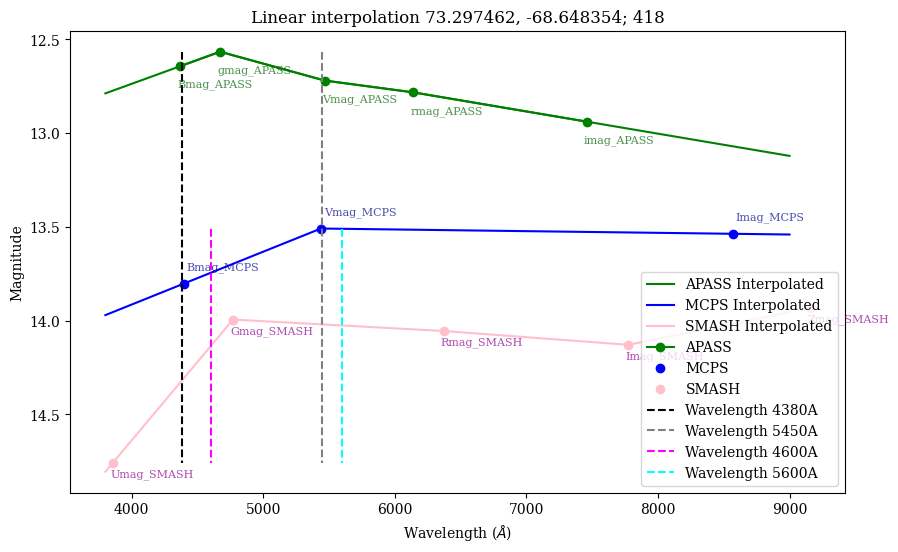

(np.float64(1.1669006925030896),
 np.float64(0.792608854352908),
 np.float64(1.5522886103543883),
 np.float64(1.293841983087077),
 np.float64(0.3913582991352911),
 np.float64(0.5156694983474743))

In [24]:
plot_lin_interp(418)

# loop for all models, and for all YSGs:

In [25]:
def synth_phot_all_models_ccm(output_filename='synth_phot_all_models.csv', batch_size=1000):
    """
    Generate synthetic photometry for all BOSZ models across different reddening values.
    
    Parameters:
    output_filename: str, filename for the output CSV file
    batch_size: int, number of rows to accumulate before writing to file
    
    Returns:
    str: path to the output file
    """
    synth_band_names = ['J', 'H', 'K', 'U', 'B', 'V', 'I', 'uvm2', 'uvw1', 'uvw2']
    reddening = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
    d_smc = 62.44 * 1e3 * 3.086e18
    d_lmc = 49.59 * 1e3 * 3.086e18
    
    headers = ['model', 'teff', 'logg', 'atmos', 'metallicity', 'av', 'lum_unscaled']
    # Add magnitude columns
    headers.extend([f'{band}_mag' for band in synth_band_names])
    # Add flux columns  
    headers.extend([f'{band}_flux' for band in synth_band_names])
    
    # Calculate total iterations for progress bar
    total_iterations = 0
    for metallicity_group in [smc_bosz, lmc_bosz]:
        total_iterations += len(metallicity_group) * len(reddening)
    
    print(f"Processing {total_iterations} model-reddening combinations...")
    print(f"Writing to: {output_filename}")
    
    # Initialize batch storage
    batch_data = []
    rows_written = 0
    
    with open(output_filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(headers)  # write header
        
        # Progress bar for all iterations
        pbar = tqdm(total=total_iterations, desc="Computing synthetic photometry")

        try:
            for metallicity_group in [smc_bosz, lmc_bosz]:
                for model_file in metallicity_group:
                    model = model_file['filepath']
                    model_teff = model_file['teff']
                    model_logg = model_file['logg']
                    atmos = model_file['class']
                    metallicity = model_file['metallicity']
                    
                    # Load model spectrum once per model
                    try:
                        model_flux = ascii.read(model, names=['flux','cont'], data_start=0)
                    except Exception as e:
                        print(f"\\nError reading model {model}: {e}")
                        pbar.update(len(reddening))  # Skip all reddening values for this model
                        return
                    
                    for av in reddening:
                        try:
                            # Apply reddening
                            reddened_model_flux = Cardelli_redden(wave['wave'], model_flux['flux'], Av=av)
                            
                            # Create a flux dict that matches compute_synth_photometry interface
                            flux_data = {'flux': reddened_model_flux}
                            if metallicity_group == smc_bosz:
                                lum_unscaled = 4 * np.pi * d_smc**2 * np.trapezoid(flux_data['flux'], wave['wave'])
                            else:
                                lum_unscaled = 4 * np.pi * d_lmc**2 * np.trapezoid(flux_data['flux'], wave['wave'])
                            
                            # Compute synthetic photometry
                            synth_phot = compute_synth_photometry(wave, flux_data)
                            
                            # Extract magnitudes and fluxes in the correct order
                            points_mag = [synth_phot[band]['mag'] for band in synth_band_names]
                            points_flux = [synth_phot[band]['flux'] for band in synth_band_names]
                            
                            # Create row data
                            row_data = [
                                model,           # model filepath
                                model_teff,      # model_teff  
                                model_logg,      # model_logg
                                atmos,           # atmos
                                metallicity,     # metallicity
                                av,               # av
                                lum_unscaled
                            ]
                            row_data.extend(points_mag)   # Add magnitude columns
                            row_data.extend(points_flux)  # Add flux columns
                            
                            batch_data.append(row_data)
                            
                            # Write batch if it reaches batch_size
                            if len(batch_data) >= batch_size:
                                writer.writerows(batch_data)
                                csvfile.flush()  # Ensure data is written to disk
                                rows_written += len(batch_data)
                                pbar.set_postfix(rows_written=rows_written)
                                batch_data = []  # Reset batch
                                
                        except Exception as e:
                            print(f"\\nError processing model {model} with Av={av}: {e}")
                        
                        pbar.update(1)
            
            # Write remaining batch data
            if batch_data:
                writer.writerows(batch_data)
                rows_written += len(batch_data)
                
        except KeyboardInterrupt:
            print(f"\\nComputation interrupted. Partial results saved ({rows_written} rows)")
        finally:
            pbar.close()
    
    print(f"\\nCompleted! Total rows written: {rows_written}")
    print(f"Output saved to: {output_filename}")
    
    return output_filename

# synth_phot_all_models_ccm(output_filename='synth_phot_all_models.csv', batch_size=1000)

In [26]:
def synth_phot_all_models_allphot(output_filename='synth_phot_all_models.csv', batch_size=1000):
    """
    Generate synthetic photometry for all BOSZ models across different reddening values.
    
    Parameters:
    output_filename: str, filename for the output CSV file
    batch_size: int, number of rows to accumulate before writing to file
    
    Returns:
    str: path to the output file
    """

    synth_band_keys = [
        'J_2MASS', 'H_2MASS', 'K_2MASS',  # 2MASS NIR
        'U_MCPS', 'B_MCPS', 'V_MCPS', 'I_MCPS',  # MCPS optical
        'B_APASS', 'V_APASS', 'g_APASS', 'r_APASS', 'i_APASS',  # APASS optical
        'U_GAIA', 'B_GAIA', 'V_GAIA', 'I_GAIA','g_GAIA', 'r_GAIA','i_GAIA', # Gaia optical (not used in final CSV but included for completeness)
        'U_SMASH', 'G_SMASH', 'R_SMASH', 'I_SMASH', 'Z_SMASH',  # SMASH optical
        'uvw1_SWIFT', 'uvw2_SWIFT', 'uvm2_SWIFT'  # SWIFT UV
    ]

    # Desired CSV column names
    synth_band_names = [
        'Jmag_2MASS', 'Hmag_2MASS', 'Kmag_2MASS',  # 2MASS NIR
        'Umag_MCPS', 'Bmag_MCPS', 'Vmag_MCPS', 'Imag_MCPS',  # MCPS optical
        'Bmag_APASS', 'Vmag_APASS', 'gmag_APASS', 'rmag_APASS', 'imag_APASS',  # APASS optical
        'Umag_GAIA', 'Bmag_GAIA', 'Vmag_GAIA', 'Imag_GAIA', 'gmag_GAIA', 'rmag_GAIA', 'imag_GAIA',  # Gaia optical
        'Umag_SMASH', 'Gmag_SMASH', 'Rmag_SMASH', 'Imag_SMASH', 'Zmag_SMASH',  # SMASH optical
        'uvw1mag_SWIFT', 'uvw2mag_SWIFT', 'uvm2mag_SWIFT'  # SWIFT UV
    ]
    
    reddening = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
    d_smc = 62.44 * 1e3 * 3.086e18
    d_lmc = 49.59 * 1e3 * 3.086e18
    
    headers = ['model', 'teff', 'logg', 'atmos', 'metallicity', 'av', 'lum_unscaled']
    # Add magnitude columns
    headers.extend([f'{band}' for band in synth_band_names])
    # Add flux columns  
    headers.extend([f'{band}_flux' for band in synth_band_names])
    
    # Calculate total iterations for progress bar
    total_iterations = 0
    for metallicity_group in [smc_bosz, lmc_bosz]:
        total_iterations += len(metallicity_group) * len(reddening)
    
    print(f"Processing {total_iterations} model-reddening combinations...")
    print(f"Writing to: {output_filename}")
    
    # Initialize batch storage
    batch_data = []
    rows_written = 0
    
    with open(output_filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(headers)  # write header
        
        # Progress bar for all iterations
        pbar = tqdm(total=total_iterations, desc="Computing synthetic photometry")

        try:
            for metallicity_group in [smc_bosz, lmc_bosz]:
                for model_file in metallicity_group:
                    model = model_file['filepath']
                    model_teff = model_file['teff']
                    model_logg = model_file['logg']
                    atmos = model_file['class']
                    metallicity = model_file['metallicity']
                    
                    # Load model spectrum once per model
                    try:
                        model_flux = ascii.read(model, names=['flux','cont'], data_start=0)
                    except Exception as e:
                        print(f"\nError reading model {model}: {e}")
                        pbar.update(len(reddening))  # Skip all reddening values for this model
                        return
                    
                    for av in reddening:
                        try:
                            # Apply reddening
                            # reddened_model_flux = Cardelli_redden(wave['wave'], model_flux['flux'], Av=av)
                            if metallicity_group == smc_bosz: 
                                reddened_model_flux = gordon_redden(wave['wave'], model_flux['flux'], Av=av, wave_gordon=smc_wave, AlamAv=smc_AlamAv)
                            else:
                                reddened_model_flux = gordon_redden(wave['wave'], model_flux['flux'], Av=av, wave_gordon=lmc_wave, AlamAv=lmc_AlamAv)
                            
                            # Create a flux dict that matches compute_synth_photometry interface
                            flux_data = {'flux': reddened_model_flux}
                            if metallicity_group == smc_bosz:
                                lum_unscaled = 4 * np.pi * d_smc**2 * np.trapezoid(flux_data['flux'], wave['wave'])
                            else:
                                lum_unscaled = 4 * np.pi * d_lmc**2 * np.trapezoid(flux_data['flux'], wave['wave'])
                            
                            # Compute synthetic photometry
                            synth_phot = compute_synth_photometry(wave, flux_data)
                            
                            # Extract magnitudes and fluxes in the correct order
                            points_mag = [synth_phot[band]['mag'] for band in synth_band_keys]
                            points_flux = [synth_phot[band]['flux'] for band in synth_band_keys]
                            
                            # Create row data
                            row_data = [
                                model,           # model filepath
                                model_teff,      # model_teff  
                                model_logg,      # model_logg
                                atmos,           # atmos
                                metallicity,     # metallicity
                                av,               # av
                                lum_unscaled
                            ]
                            row_data.extend(points_mag)   # Add magnitude columns
                            row_data.extend(points_flux)  # Add flux columns
                            
                            batch_data.append(row_data)
                            
                            # Write batch if it reaches batch_size
                            if len(batch_data) >= batch_size:
                                writer.writerows(batch_data)
                                csvfile.flush()  # Ensure data is written to disk
                                rows_written += len(batch_data)
                                pbar.set_postfix(rows_written=rows_written)
                                batch_data = []  # Reset batch
                                
                        except Exception as e:
                            print(f"\nError processing model {model} with Av={av}: {e}")
                        
                        pbar.update(1)
            
            # Write remaining batch data
            if batch_data:
                writer.writerows(batch_data)
                rows_written += len(batch_data)
                
        except KeyboardInterrupt:
            print(f"\nComputation interrupted. Partial results saved ({rows_written} rows)")
        finally:
            pbar.close()
    
    print(f"\nCompleted! Total rows written: {rows_written}")
    print(f"Output saved to: {output_filename}")
    
    return output_filename

synth_phot_all_models_allphot(output_filename='synth_phot_all_models_allphot_gordon_gaia.csv', batch_size=1000)

Processing 5082 model-reddening combinations...
Writing to: synth_phot_all_models_allphot_gordon_gaia.csv


Computing synthetic photometry: 100%|██████████| 5082/5082 [00:46<00:00, 108.39it/s, rows_written=5000]


Completed! Total rows written: 5082
Output saved to: synth_phot_all_models_allphot_gordon_gaia.csv


'synth_phot_all_models_allphot_gordon_gaia.csv'

In [33]:
# Test what compute_synth_photometry returns
test_model = ascii.read(smc_bosz[0]['filepath'], names=['flux','cont'], data_start=0)
flux_data = {'flux': test_model['flux']}
synth_phot = compute_synth_photometry(wave, flux_data)
print("Keys returned by compute_synth_photometry:")
print(list(synth_phot.keys()))

Keys returned by compute_synth_photometry:
['J_2MASS', 'H_2MASS', 'K_2MASS', 'U_MCPS', 'B_MCPS', 'V_MCPS', 'I_MCPS', 'B_APASS', 'V_APASS', 'g_APASS', 'r_APASS', 'i_APASS', 'U_SMASH', 'G_SMASH', 'R_SMASH', 'I_SMASH', 'Z_SMASH', 'uvw1_SWIFT', 'uvw2_SWIFT', 'uvm2_SWIFT']


In [ ]:
def synth_phot_all_models_smash(output_filename='synth_phot_all_models.csv', batch_size=1000):
    """
    Generate synthetic photometry for all BOSZ models across different reddening values.
    
    Parameters:
    output_filename: str, filename for the output CSV file
    batch_size: int, number of rows to accumulate before writing to file
    
    Returns:
    str: path to the output file
    """
    synth_band_names = ['J', 'H', 'K', 'Usmash', 'B', 'V', 'I', 'uvm2', 'uvw1', 'uvw2']
    reddening = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]
    d_smc = 62.44 * 1e3 * 3.086e18
    d_lmc = 49.59 * 1e3 * 3.086e18
    
    headers = ['model', 'teff', 'logg', 'atmos', 'metallicity', 'av', 'lum_unscaled']
    # Add magnitude columns
    headers.extend([f'{band}_mag' for band in synth_band_names])
    # Add flux columns  
    headers.extend([f'{band}_flux' for band in synth_band_names])
    
    # Calculate total iterations for progress bar
    total_iterations = 0
    for metallicity_group in [smc_bosz, lmc_bosz]:
        total_iterations += len(metallicity_group) * len(reddening)
    
    print(f"Processing {total_iterations} model-reddening combinations...")
    print(f"Writing to: {output_filename}")
    
    # Initialize batch storage
    batch_data = []
    rows_written = 0
    
    with open(output_filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(headers)  # write header
        
        # Progress bar for all iterations
        pbar = tqdm(total=total_iterations, desc="Computing synthetic photometry")

        try:
            for metallicity_group in [smc_bosz, lmc_bosz]:
                for model_file in metallicity_group:
                    model = model_file['filepath']
                    model_teff = model_file['teff']
                    model_logg = model_file['logg']
                    atmos = model_file['class']
                    metallicity = model_file['metallicity']
                    
                    # Load model spectrum once per model
                    try:
                        model_flux = ascii.read(model, names=['flux','cont'], data_start=0)
                    except Exception as e:
                        print(f"\\nError reading model {model}: {e}")
                        pbar.update(len(reddening))  # Skip all reddening values for this model
                        return
                    
                    for av in reddening:
                        try:
                            # Apply reddening
                            reddened_model_flux = Cardelli_redden(wave['wave'], model_flux['flux'], Av=av)
                            
                            # Create a flux dict that matches compute_synth_photometry interface
                            flux_data = {'flux': reddened_model_flux}
                            if metallicity_group == smc_bosz:
                                lum_unscaled = 4 * np.pi * d_smc**2 * np.trapezoid(flux_data['flux'], wave['wave'])
                            else:
                                lum_unscaled = 4 * np.pi * d_lmc**2 * np.trapezoid(flux_data['flux'], wave['wave'])
                            
                            # Compute synthetic photometry
                            synth_phot = compute_synth_photometry(wave, flux_data)
                            
                            # Extract magnitudes and fluxes in the correct order
                            points_mag = [synth_phot[band]['mag'] for band in synth_band_names]
                            points_flux = [synth_phot[band]['flux'] for band in synth_band_names]
                            
                            # Create row data
                            row_data = [
                                model,           # model filepath
                                model_teff,      # model_teff  
                                model_logg,      # model_logg
                                atmos,           # atmos
                                metallicity,     # metallicity
                                av,               # av
                                lum_unscaled
                            ]
                            row_data.extend(points_mag)   # Add magnitude columns
                            row_data.extend(points_flux)  # Add flux columns
                            
                            batch_data.append(row_data)
                            
                            # Write batch if it reaches batch_size
                            if len(batch_data) >= batch_size:
                                writer.writerows(batch_data)
                                csvfile.flush()  # Ensure data is written to disk
                                rows_written += len(batch_data)
                                pbar.set_postfix(rows_written=rows_written)
                                batch_data = []  # Reset batch
                                
                        except Exception as e:
                            print(f"\\nError processing model {model} with Av={av}: {e}")
                        
                        pbar.update(1)
            
            # Write remaining batch data
            if batch_data:
                writer.writerows(batch_data)
                rows_written += len(batch_data)
                
        except KeyboardInterrupt:
            print(f"\\nComputation interrupted. Partial results saved ({rows_written} rows)")
        finally:
            pbar.close()
    
    print(f"\\nCompleted! Total rows written: {rows_written}")
    print(f"Output saved to: {output_filename}")
    
    return output_filename

# synth_phot_all_models(output_filename='synth_phot_all_models.csv', batch_size=1000)

# for unusual/interesting stars:

# Teff not far off:

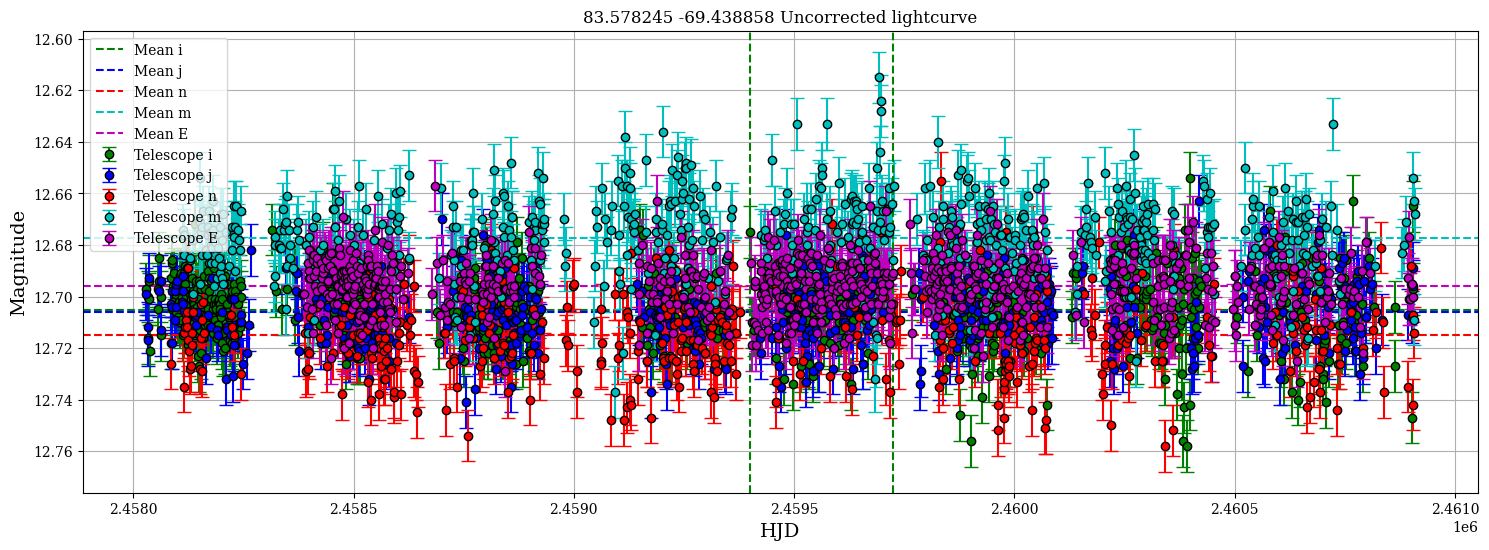

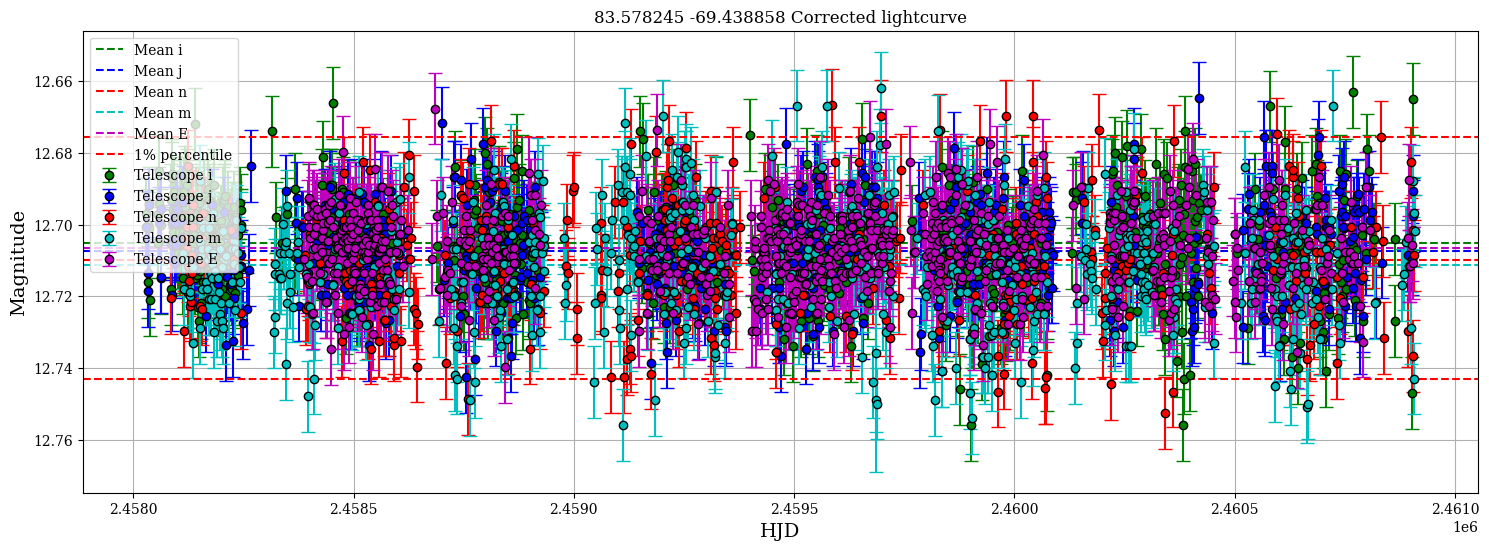

Best frequency: 0.263114 1/day, Best period: 3.80 days, Max power: 0.023, False alarm probability: 6.057e-11
False alarm level for 1.0%: 9.875e-03
Grid sampled at 26961 points


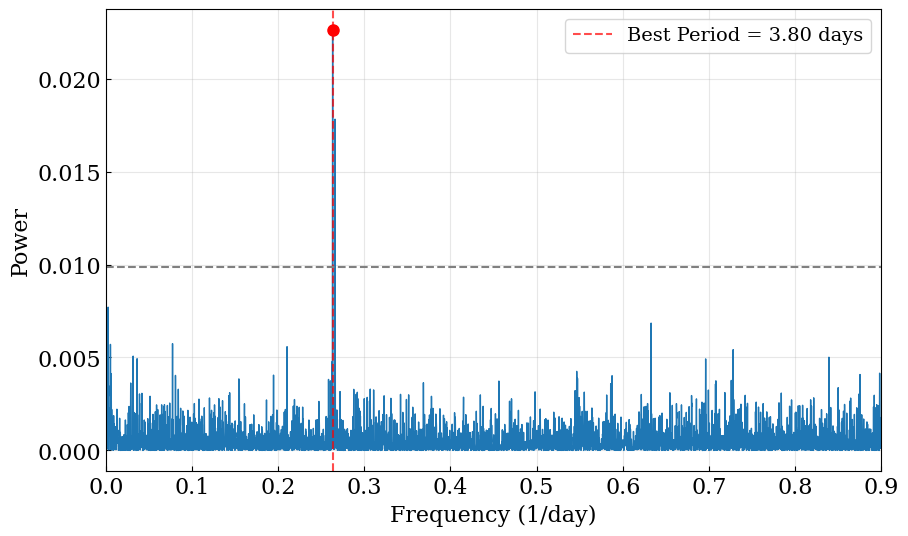

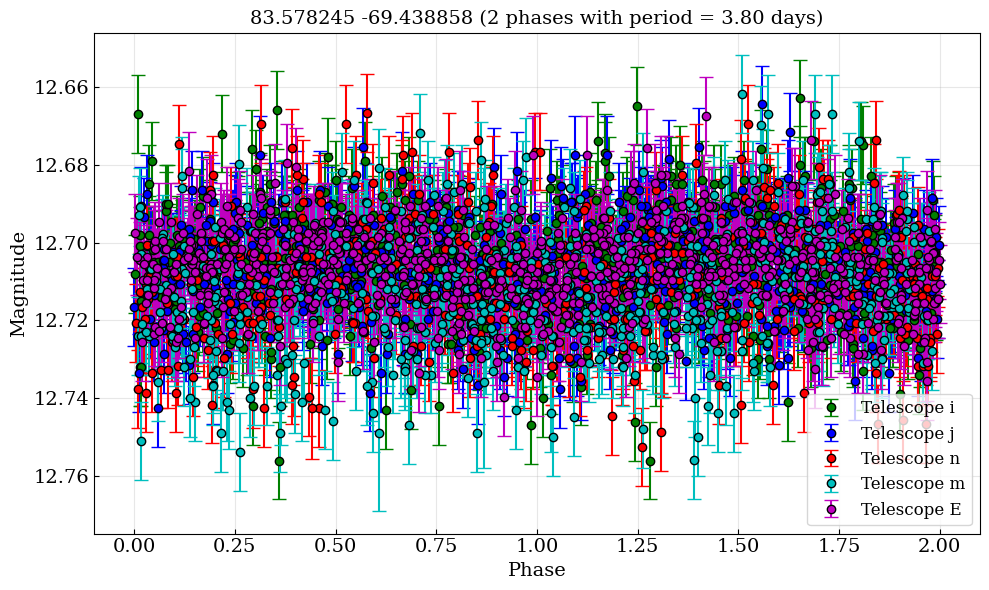

Average scatter (amplitude) per 10 point phase bin: 1.079 mJy


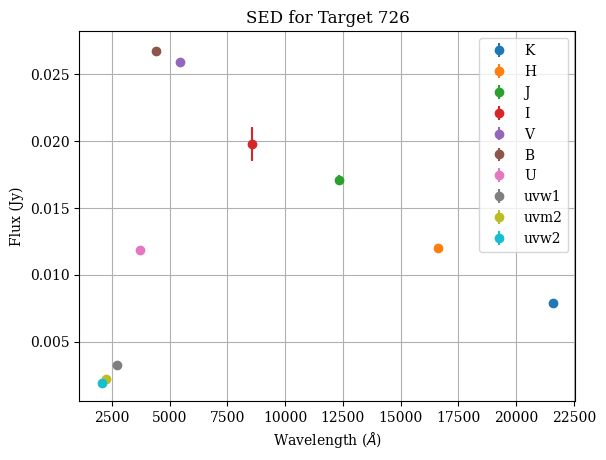

[0.2631144  0.26591639]
Amplitude metrics:
	Lower 5% percentile: -0.63 mJy, 12.69 mags
	Upper 5% percentile: 0.57 mJy, 12.73 mags
	Percentile amplitude of variability (excluding the brightest and dimmest 5% of data) (g-band: True): 1.20 mJy, 0.04 mags
Amplitude metrics:
	Lower 1% percentile: -0.96 mJy, 12.68 mags
	Upper 1% percentile: 0.89 mJy, 12.74 mags
	Percentile amplitude of variability (excluding the brightest and dimmest 1% of data) (g-band: True): 1.85 mJy, 0.07 mags
	Largest amplitude of variability (g-band: True): 2.60 mJy, 0.09 mags
	Average amplitude across all periods: 0.883 mJy
	Standard deviation of amplitudes: 0.372 mJy


/var/folders/34/3847lqd14j78mfm70_z1c_r00000gn/T/ipykernel_12447/3677652267.py:141: RuntimeWarning: divide by zero encountered in log10
  plt.plot(wave['wave'], -2.5 * np.log10(newflux/tmass_k_zp), #+ plot_mag_shift,


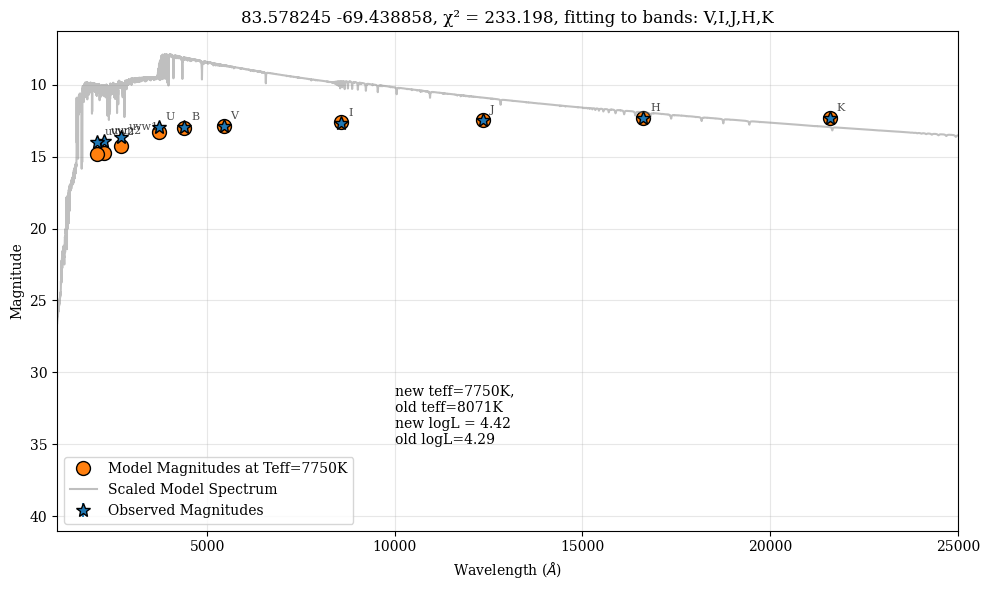

Previous Teff: 8070.890238426216K, logT_old = 3.9069214410804887. New fit Teff: 7750K, logT_new = 3.88930170250631


In [26]:
info(726)
new_teff = model_fitting[model_fitting['star_index'] == 726][['teff_cut_1']]
fit_models_to_star(star_idx=726, show=True)
print(f"Previous Teff: {model_fitting[model_fitting['star_index'] == 726]['orig_teff'].iloc[0]}K, logT_old = {model_fitting[model_fitting['star_index'] == 726]['orig_logT'].iloc[0]}. New fit Teff: {model_fitting[model_fitting['star_index'] == 726]['teff_cut_1'].iloc[0]}K, logT_new = {model_fitting[model_fitting['star_index'] == 726]['logT_cut_1'].iloc[0]}")

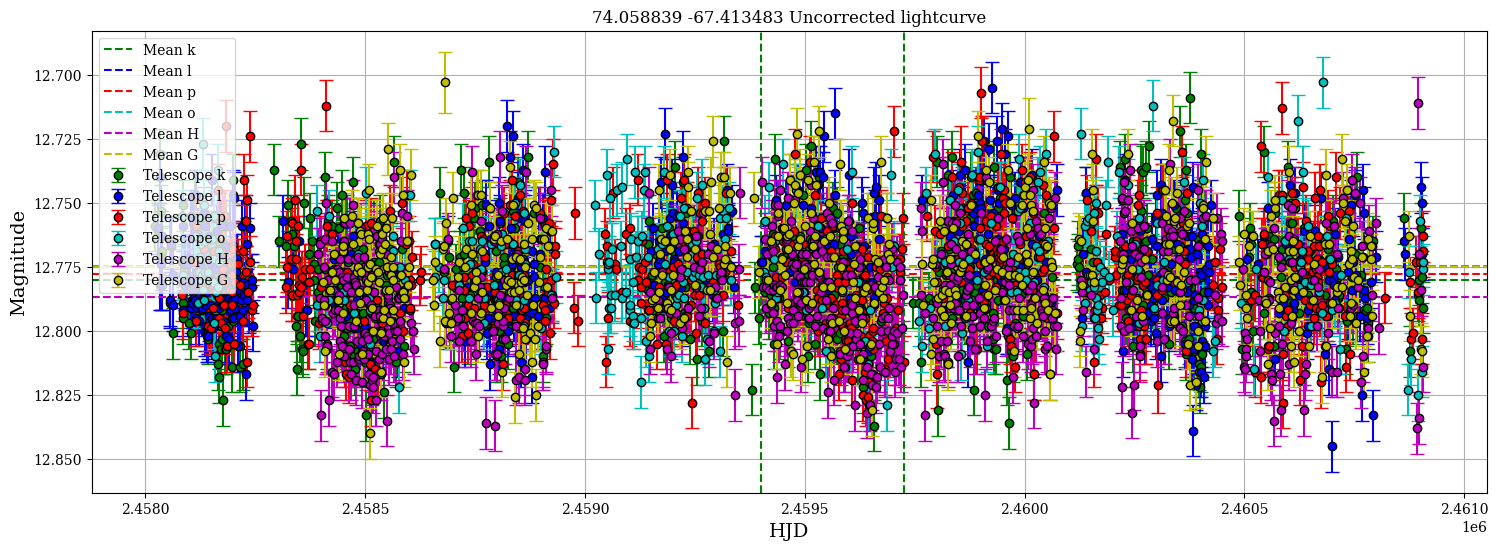

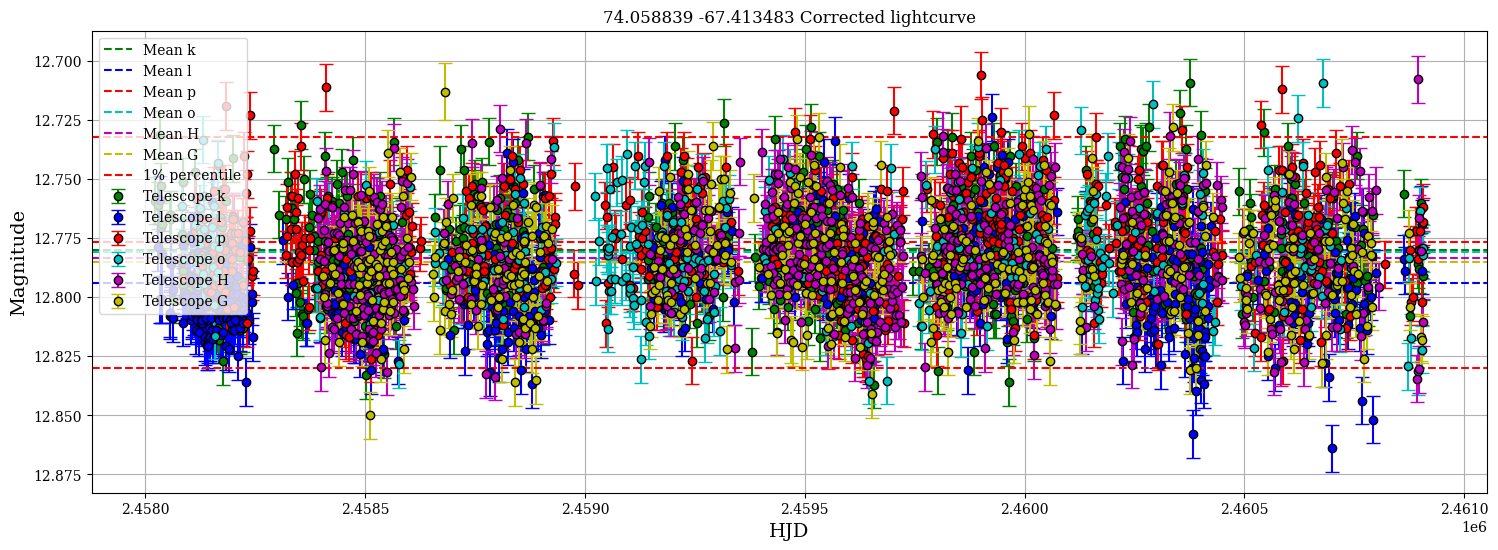

Best frequency: 0.277344 1/day, Best period: 3.61 days, Max power: 0.246, False alarm probability: 4.538e-203
False alarm level for 1.0%: 8.839e-03
Grid sampled at 30486 points


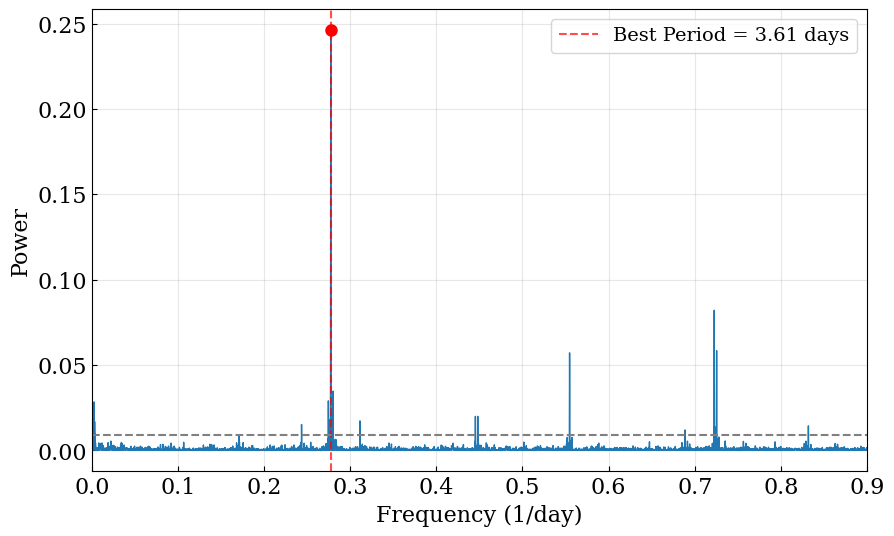

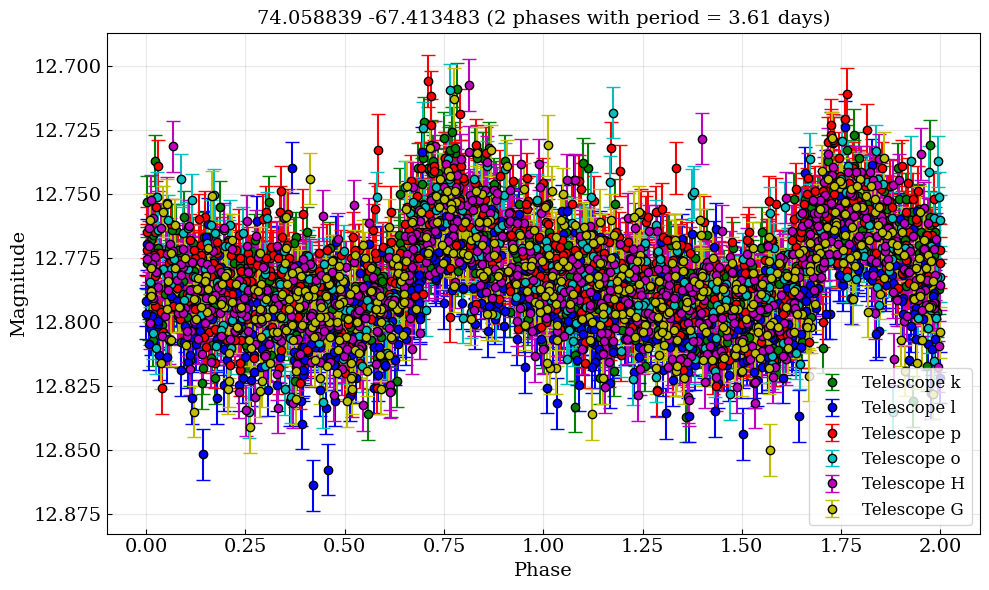

Average scatter (amplitude) per 10 point phase bin: 1.318 mJy


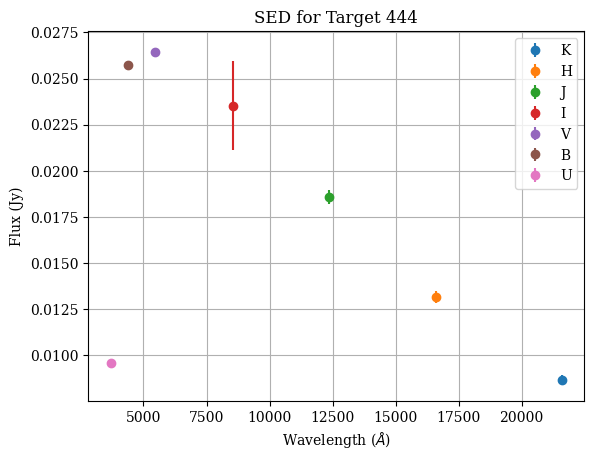

[0.00131278 0.00258128 0.00314178 0.00349578 0.24344857 0.27457104
 0.27684254 0.27734404 0.27784554 0.28011704 0.31129851 0.4453169
 0.44808989 0.5547028  0.68875068 0.72267565 0.72317715 0.72544865
 0.83203206]
Amplitude metrics:
	Lower 5% percentile: -0.80 mJy, 12.75 mags
	Upper 5% percentile: 1.01 mJy, 12.82 mags
	Percentile amplitude of variability (excluding the brightest and dimmest 5% of data) (g-band: True): 1.80 mJy, 0.07 mags
Amplitude metrics:
	Lower 1% percentile: -1.14 mJy, 12.73 mags
	Upper 1% percentile: 1.39 mJy, 12.83 mags
	Percentile amplitude of variability (excluding the brightest and dimmest 1% of data) (g-band: True): 2.52 mJy, 0.10 mags
	Largest amplitude of variability (g-band: True): 4.06 mJy, 0.16 mags
	Average amplitude across all periods: 1.353 mJy
	Standard deviation of amplitudes: 0.464 mJy


/var/folders/34/3847lqd14j78mfm70_z1c_r00000gn/T/ipykernel_12447/3677652267.py:141: RuntimeWarning: divide by zero encountered in log10
  plt.plot(wave['wave'], -2.5 * np.log10(newflux/tmass_k_zp), #+ plot_mag_shift,


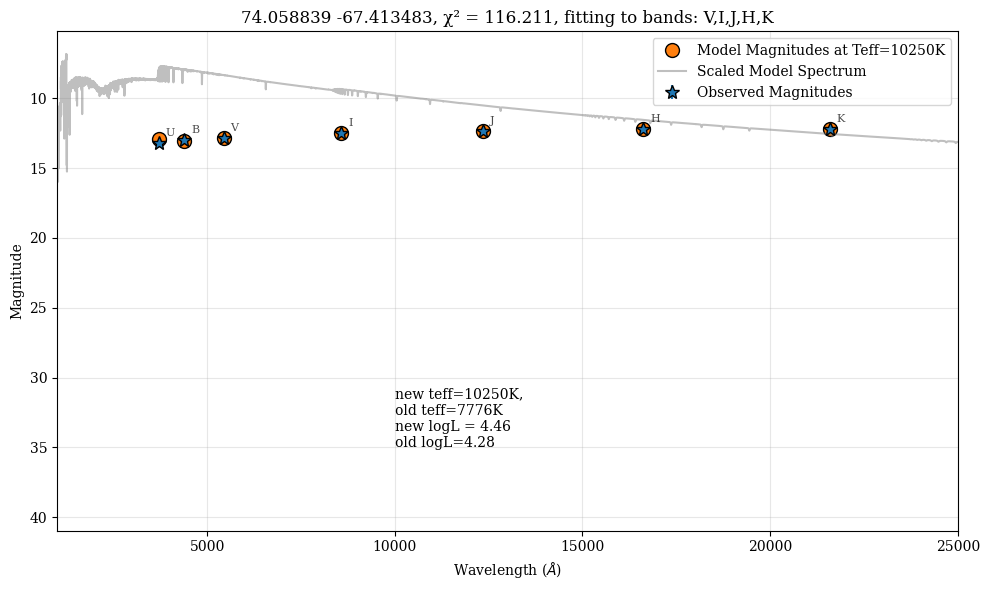

Previous Teff: 7775.65131502553K, logT_old = 3.890736777206846. New fit Teff: 10250K, logT_new = 4.010723865391773


In [27]:
target_index=444
info(target_index)
new_teff = fit_models_to_star(target_index, show=True)
print(f"Previous Teff: {model_fitting[model_fitting['star_index'] == target_index]['orig_teff'].iloc[0]}K, logT_old = {model_fitting[model_fitting['star_index'] == target_index]['orig_logT'].iloc[0]}. New fit Teff: {model_fitting[model_fitting['star_index'] == target_index]['teff_cut_1'].iloc[0]}K, logT_new = {model_fitting[model_fitting['star_index'] == target_index]['logT_cut_1'].iloc[0]}")

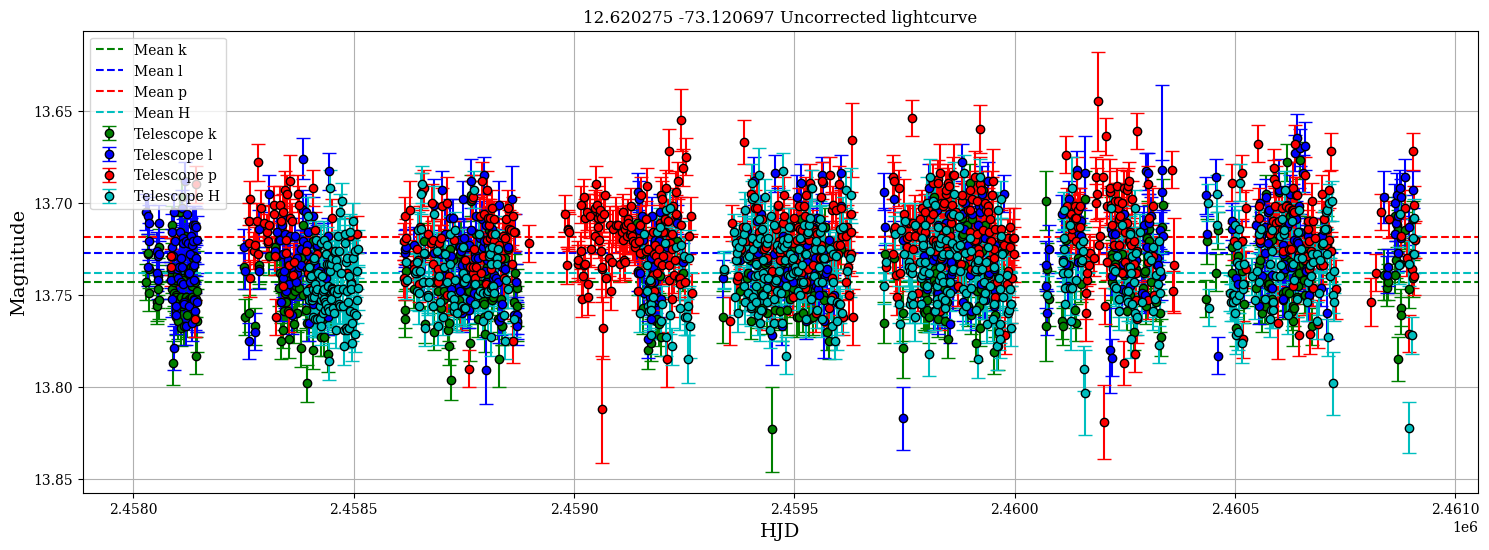

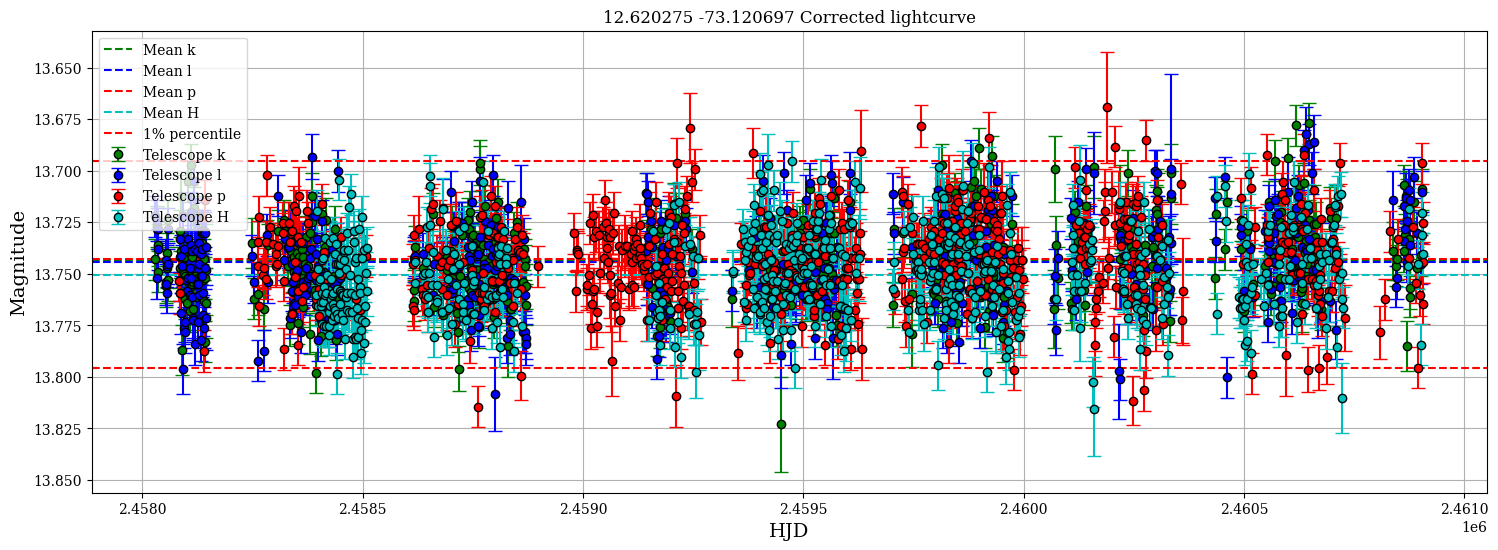

Best frequency: 0.167929 1/day, Best period: 5.95 days, Max power: 0.216, False alarm probability: 7.312e-111
False alarm level for 1.0%: 1.328e-02
Grid sampled at 19586 points


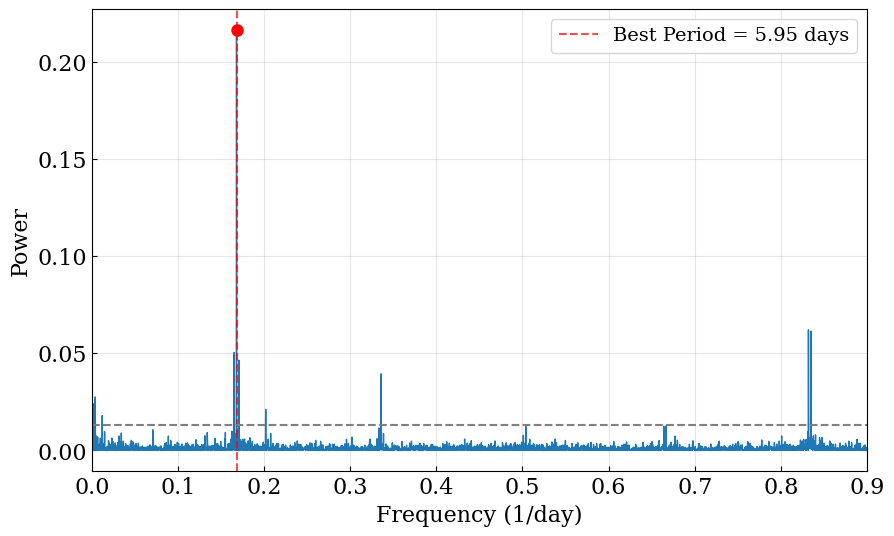

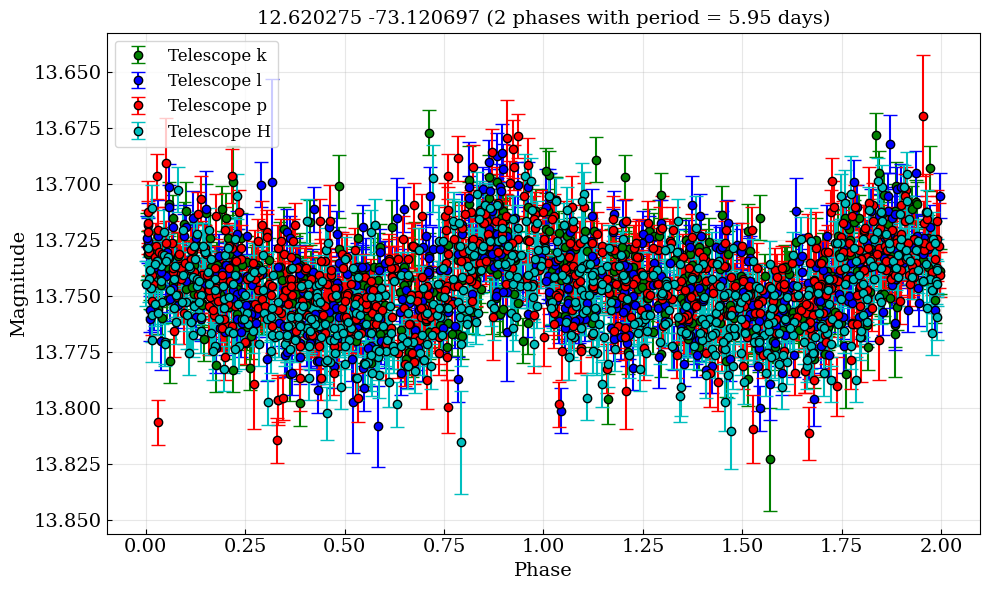

Average scatter (amplitude) per 10 point phase bin: 0.586 mJy


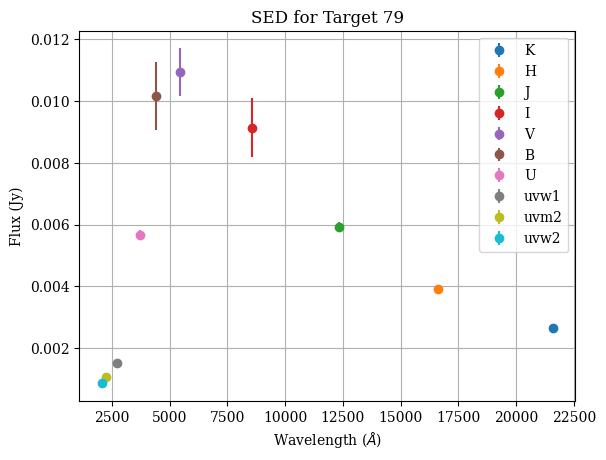

[0.00253169 0.00386332 0.01199081 0.16512751 0.16792851 0.17072951
 0.20181603 0.33585083 0.8320872  0.8348882 ]
Amplitude metrics:
	Lower 5% percentile: -0.34 mJy, 13.71 mags
	Upper 5% percentile: 0.37 mJy, 13.78 mags
	Percentile amplitude of variability (excluding the brightest and dimmest 5% of data) (g-band: True): 0.71 mJy, 0.07 mags
Amplitude metrics:
	Lower 1% percentile: -0.52 mJy, 13.70 mags
	Upper 1% percentile: 0.55 mJy, 13.80 mags
	Percentile amplitude of variability (excluding the brightest and dimmest 1% of data) (g-band: True): 1.06 mJy, 0.10 mags
	Largest amplitude of variability (g-band: True): 1.63 mJy, 0.15 mags
	Average amplitude across all periods: 0.590 mJy
	Standard deviation of amplitudes: 0.214 mJy


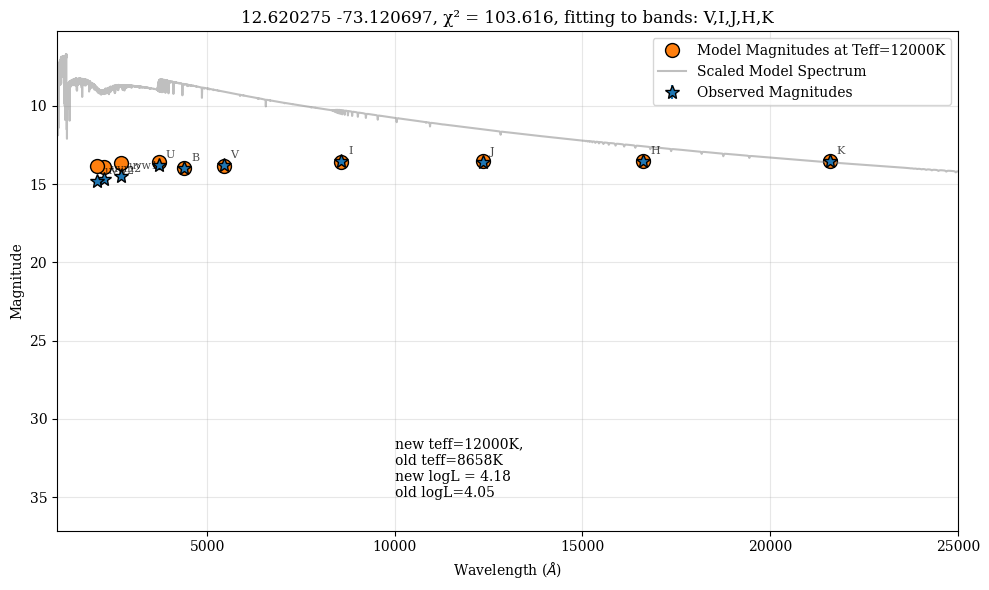

Previous Teff: 8658.05292675768K, logT_old = 3.93742023633144. New fit Teff: 12000K, logT_new = 4.079181246047625


In [28]:
target_index=79
info(target_index)
new_teff = fit_models_to_star(target_index, show=True)
print(f"Previous Teff: {model_fitting[model_fitting['star_index'] == target_index]['orig_teff'].iloc[0]}K, logT_old = {model_fitting[model_fitting['star_index'] == target_index]['orig_logT'].iloc[0]}. New fit Teff: {model_fitting[model_fitting['star_index'] == target_index]['teff_cut_1'].iloc[0]}K, logT_new = {model_fitting[model_fitting['star_index'] == target_index]['logT_cut_1'].iloc[0]}")

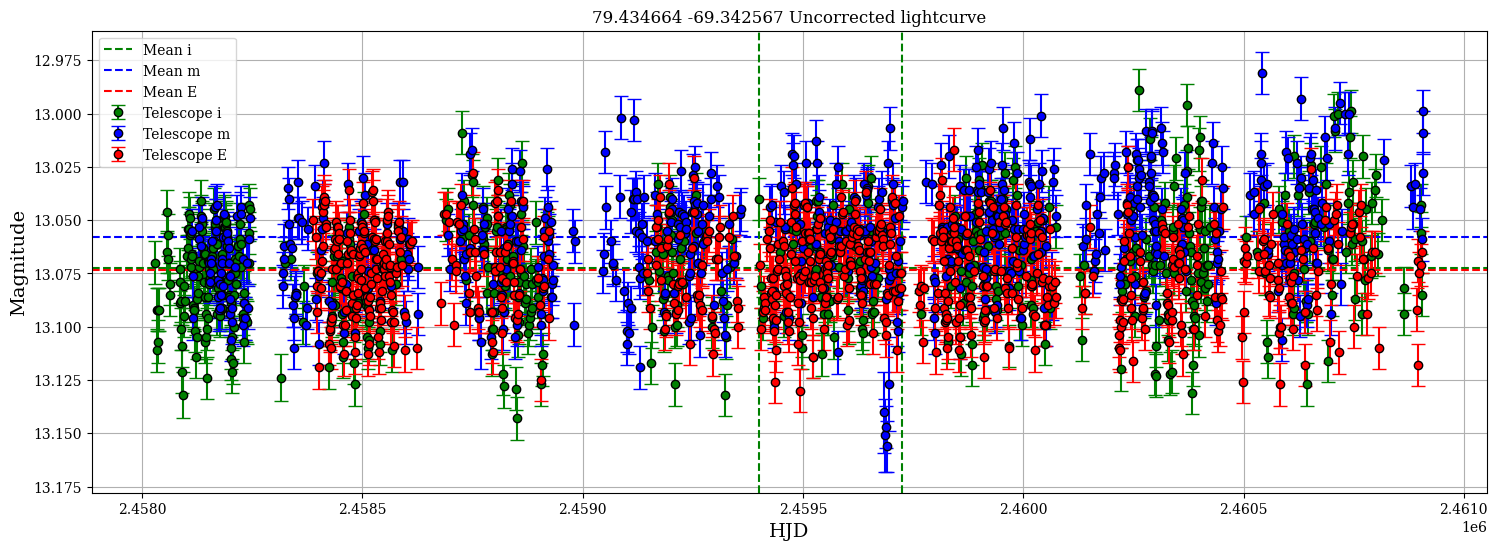

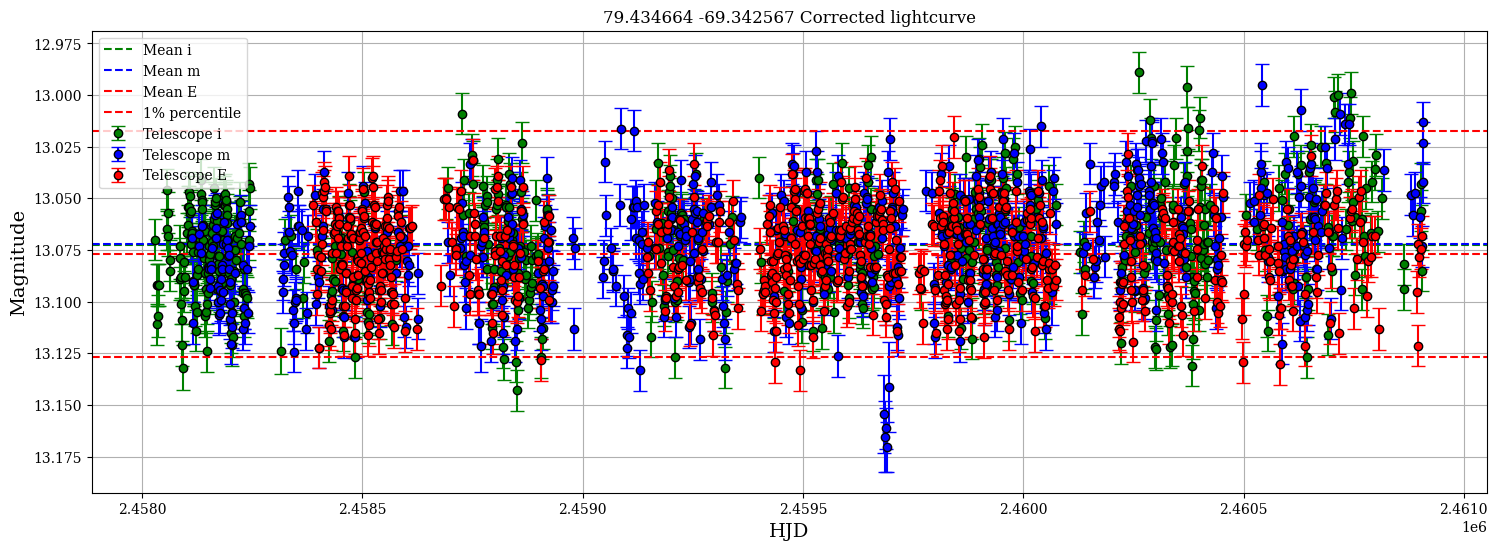

Best frequency: 0.035737 1/day, Best period: 27.98 days, Max power: 0.495, False alarm probability: 1.525e-290
False alarm level for 1.0%: 1.442e-02
Grid sampled at 17914 points


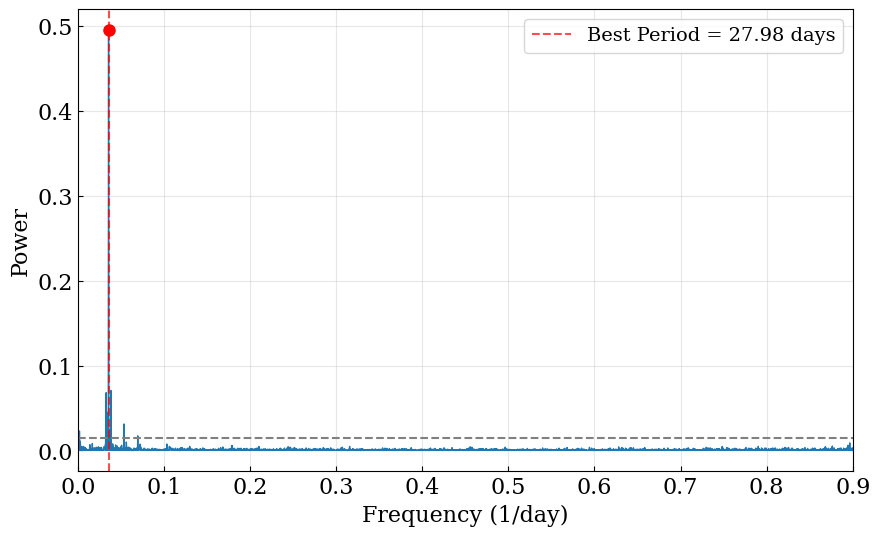

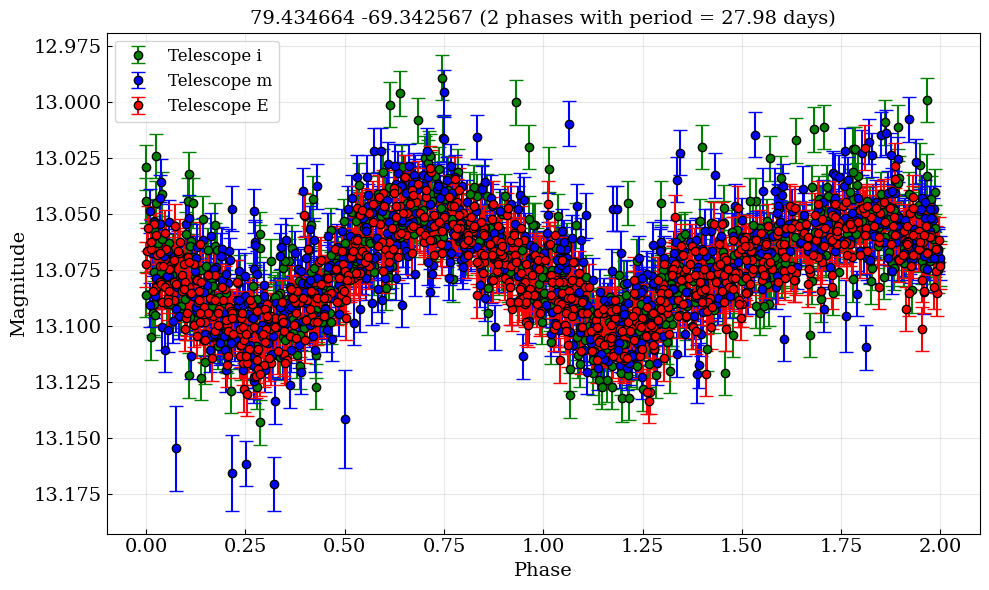

Average scatter (amplitude) per 10 point phase bin: 0.972 mJy


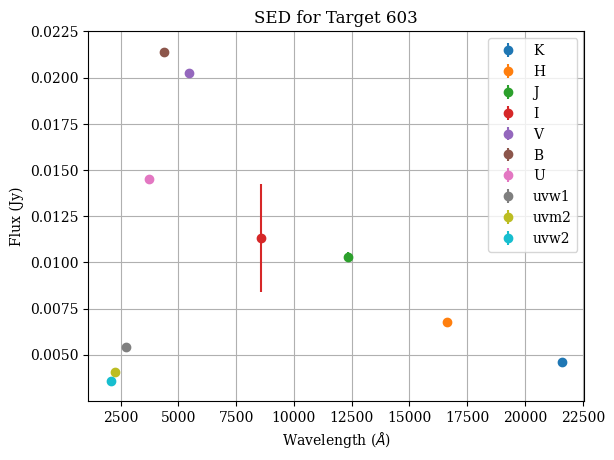

[0.00189962 0.03242368 0.03297593 0.03518491 0.03573715 0.03623919
 0.03849838 0.05355959 0.06962489]
Amplitude metrics:
	Lower 5% percentile: -0.77 mJy, 13.04 mags
	Upper 5% percentile: 0.72 mJy, 13.11 mags
	Percentile amplitude of variability (excluding the brightest and dimmest 5% of data) (g-band: True): 1.49 mJy, 0.08 mags
Amplitude metrics:
	Lower 1% percentile: -1.02 mJy, 13.02 mags
	Upper 1% percentile: 1.15 mJy, 13.13 mags
	Percentile amplitude of variability (excluding the brightest and dimmest 1% of data) (g-band: True): 2.17 mJy, 0.11 mags
	Largest amplitude of variability (g-band: True): 3.55 mJy, 0.18 mags
	Average amplitude across all periods: 1.684 mJy
	Standard deviation of amplitudes: 0.353 mJy


/var/folders/34/3847lqd14j78mfm70_z1c_r00000gn/T/ipykernel_12447/3677652267.py:141: RuntimeWarning: divide by zero encountered in log10
  plt.plot(wave['wave'], -2.5 * np.log10(newflux/tmass_k_zp), #+ plot_mag_shift,


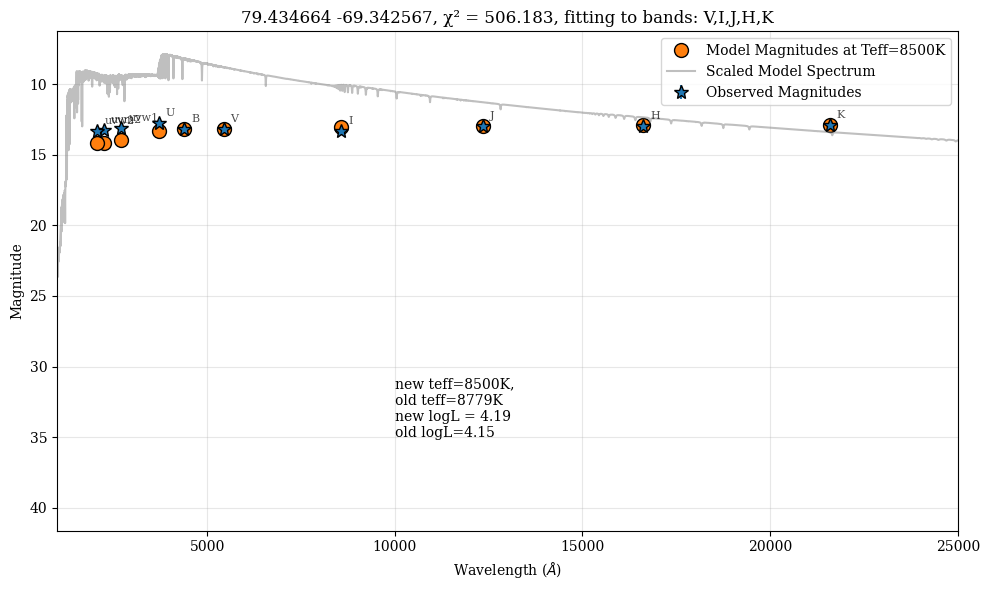

Previous Teff: 8779.396732960868K, logT_old = 3.943464674841481. New fit Teff: 8500K, logT_new = 3.929418925714293


In [29]:
target_index=603
info(target_index)
new_teff = fit_models_to_star(target_index, show=True)
print(f"Previous Teff: {model_fitting[model_fitting['star_index'] == target_index]['orig_teff'].iloc[0]}K, logT_old = {model_fitting[model_fitting['star_index'] == target_index]['orig_logT'].iloc[0]}. New fit Teff: {model_fitting[model_fitting['star_index'] == target_index]['teff_cut_1'].iloc[0]}K, logT_new = {model_fitting[model_fitting['star_index'] == target_index]['logT_cut_1'].iloc[0]}")